# Full Benchmark Evaluation

**Goal:** Unified comparison of all oversampling methods under identical conditions.

| Method | Type |
|---|---|
| No Resampling | Baseline |
| Class Weights | Baseline |
| SMOTE | Classical |
| CTGAN | Generative |
| TVAE | Generative |

**Classifiers:** Logistic Regression, Random Forest  
**Metrics:** F1, PR-AUC, MCC

> CTGAN/TVAE synthetic data is cached to CSV after first run to avoid retraining.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix,
    precision_recall_curve, PrecisionRecallDisplay
)
from imblearn.over_sampling import SMOTENC
from sdv.single_table import CTGANSynthesizer, TVAESynthesizer
from sdv.metadata import SingleTableMetadata

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

DATA_PATH         = Path('../data/healthcare-dataset-stroke-data.csv')
CTGAN_CACHE       = Path('../data/synthetic_ctgan.csv')
TVAE_CACHE        = Path('../data/synthetic_tvae.csv')
RANDOM_STATE      = 42

NUMERICAL   = ['age', 'avg_glucose_level', 'bmi']
CATEGORICAL = ['hypertension', 'heart_disease', 'gender', 'ever_married',
               'work_type', 'Residence_type', 'smoking_status']

## 1. Load & Preprocess

In [2]:
df = pd.read_csv(DATA_PATH)
df = df.drop(columns=['id'])
df = df[df['gender'] != 'Other'].copy()
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# Raw split (for generative models)
train_raw, test_raw = train_test_split(
    df, test_size=0.2, random_state=RANDOM_STATE, stratify=df['stroke']
)

# Encoded split (for classifiers and SMOTE)
enc = OrdinalEncoder()
df_enc = df.copy()
df_enc[CATEGORICAL] = enc.fit_transform(df[CATEGORICAL])

X = df_enc[NUMERICAL + CATEGORICAL].values
y = df_enc['stroke'].values
cat_indices = list(range(len(NUMERICAL), len(NUMERICAL) + len(CATEGORICAL)))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
n = len(NUMERICAL)
X_train_s = np.hstack([scaler.fit_transform(X_train[:, :n]), X_train[:, n:]])
X_test_s  = np.hstack([scaler.transform(X_test[:, :n]),      X_test[:, n:]])

n_majority    = (y_train == 0).sum()
n_minority    = (y_train == 1).sum()
n_to_generate = n_majority - n_minority

print(f'Train: {X_train_s.shape} | Stroke: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Test:  {X_test_s.shape}  | Stroke: {y_test.sum()} ({y_test.mean()*100:.1f}%)')
print(f'Samples to generate: {n_to_generate}')

Train: (4087, 10) | Stroke: 199 (4.9%)
Test:  (1022, 10)  | Stroke: 50 (4.9%)
Samples to generate: 3689


## 2. Generate Synthetic Data

SMOTE is applied inline. CTGAN/TVAE synthetic data is cached to CSV — training runs only on the first execution.

In [3]:
# --- SMOTE ---
smotenc = SMOTENC(categorical_features=cat_indices, random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smotenc.fit_resample(X_train_s, y_train)
print(f'SMOTE: {X_train_smote.shape} | Stroke: {y_train_smote.sum()} ({y_train_smote.mean()*100:.1f}%)')

SMOTE: (7776, 10) | Stroke: 3888 (50.0%)


In [4]:
def build_augmented(synthetic_raw):
    """Combine raw train data with synthetic samples, encode and scale."""
    combined = pd.concat([train_raw, synthetic_raw], ignore_index=True)
    enc2 = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    combined[CATEGORICAL] = enc2.fit_transform(combined[CATEGORICAL])
    X_tr = combined[NUMERICAL + CATEGORICAL].values
    y_tr = combined['stroke'].values

    test_enc = test_raw.copy()
    test_enc[CATEGORICAL] = enc2.transform(test_raw[CATEGORICAL])
    X_te = test_enc[NUMERICAL + CATEGORICAL].values

    sc2 = StandardScaler()
    X_tr_s = np.hstack([sc2.fit_transform(X_tr[:, :n]), X_tr[:, n:]])
    X_te_s = np.hstack([sc2.transform(X_te[:, :n]),     X_te[:, n:]])
    return X_tr_s, y_tr, X_te_s

In [5]:
# --- CTGAN ---
if CTGAN_CACHE.exists():
    synthetic_ctgan = pd.read_csv(CTGAN_CACHE)
    print(f'CTGAN: loaded from cache ({len(synthetic_ctgan)} samples)')
else:
    minority_train = train_raw[train_raw['stroke'] == 1].copy()
    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(minority_train)
    for col in NUMERICAL:
        metadata.update_column(col, sdtype='numerical')
    for col in CATEGORICAL + ['stroke']:
        metadata.update_column(col, sdtype='categorical')

    ctgan = CTGANSynthesizer(metadata, epochs=300, verbose=True)
    ctgan.fit(minority_train)
    synthetic_ctgan = ctgan.sample(num_rows=n_to_generate)
    synthetic_ctgan['stroke'] = 1
    synthetic_ctgan.to_csv(CTGAN_CACHE, index=False)
    print(f'CTGAN: trained and cached ({len(synthetic_ctgan)} samples)')

X_train_ctgan, y_train_ctgan, X_test_ctgan = build_augmented(synthetic_ctgan)

/home/cmakri/.local/lib/python3.10/site-packages/sdv/single_table/base.py:178: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

/home/cmakri/.local/lib/python3.10/site-packages/sdv/single_table/base.py:134: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.



  0%|          | 0/300 [00:00<?, ?it/s]

Gen. (+00.00) | Discrim. (+00.00):   0%|          | 0/300 [00:00<?, ?it/s]

Gen. (+00.79) | Discrim. (+00.03):   0%|          | 0/300 [00:01<?, ?it/s]

Gen. (+00.79) | Discrim. (+00.03):   0%|          | 1/300 [00:01<07:27,  1.50s/it]

Gen. (+00.80) | Discrim. (+00.01):   0%|          | 1/300 [00:01<07:27,  1.50s/it]

Gen. (+00.83) | Discrim. (-00.01):   0%|          | 1/300 [00:01<07:27,  1.50s/it]

Gen. (+00.77) | Discrim. (-00.01):   0%|          | 1/300 [00:01<07:27,  1.50s/it]

Gen. (+00.77) | Discrim. (-00.01):   1%|▏         | 4/300 [00:01<01:34,  3.14it/s]

Gen. (+00.78) | Discrim. (-00.00):   1%|▏         | 4/300 [00:01<01:34,  3.14it/s]

Gen. (+00.79) | Discrim. (-00.02):   1%|▏         | 4/300 [00:01<01:34,  3.14it/s]

Gen. (+00.78) | Discrim. (-00.08):   1%|▏         | 4/300 [00:01<01:34,  3.14it/s]

Gen. (+00.78) | Discrim. (-00.08):   2%|▏         | 7/300 [00:01<00:50,  5.78it/s]

Gen. (+00.78) | Discrim. (-00.05):   2%|▏         | 7/300 [00:01<00:50,  5.78it/s]

Gen. (+00.71) | Discrim. (-00.07):   2%|▏         | 7/300 [00:01<00:50,  5.78it/s]

Gen. (+00.74) | Discrim. (-00.09):   2%|▏         | 7/300 [00:01<00:50,  5.78it/s]

Gen. (+00.74) | Discrim. (-00.09):   3%|▎         | 10/300 [00:01<00:36,  8.02it/s]

Gen. (+00.77) | Discrim. (-00.09):   3%|▎         | 10/300 [00:02<00:36,  8.02it/s]

Gen. (+00.74) | Discrim. (-00.13):   3%|▎         | 10/300 [00:02<00:36,  8.02it/s]

Gen. (+00.69) | Discrim. (-00.10):   3%|▎         | 10/300 [00:02<00:36,  8.02it/s]

Gen. (+00.69) | Discrim. (-00.10):   4%|▍         | 13/300 [00:02<00:27, 10.60it/s]

Gen. (+00.70) | Discrim. (-00.13):   4%|▍         | 13/300 [00:02<00:27, 10.60it/s]

Gen. (+00.67) | Discrim. (-00.17):   4%|▍         | 13/300 [00:02<00:27, 10.60it/s]

Gen. (+00.64) | Discrim. (-00.17):   4%|▍         | 13/300 [00:02<00:27, 10.60it/s]

Gen. (+00.64) | Discrim. (-00.17):   5%|▌         | 16/300 [00:02<00:21, 13.08it/s]

Gen. (+00.57) | Discrim. (-00.10):   5%|▌         | 16/300 [00:02<00:21, 13.08it/s]

Gen. (+00.50) | Discrim. (-00.01):   5%|▌         | 16/300 [00:02<00:21, 13.08it/s]

Gen. (+00.56) | Discrim. (-00.06):   5%|▌         | 16/300 [00:02<00:21, 13.08it/s]

Gen. (+00.56) | Discrim. (-00.06):   6%|▋         | 19/300 [00:02<00:18, 15.26it/s]

Gen. (+00.46) | Discrim. (-00.06):   6%|▋         | 19/300 [00:02<00:18, 15.26it/s]

Gen. (+00.47) | Discrim. (-00.10):   6%|▋         | 19/300 [00:02<00:18, 15.26it/s]

Gen. (+00.39) | Discrim. (-00.14):   6%|▋         | 19/300 [00:02<00:18, 15.26it/s]

Gen. (+00.39) | Discrim. (-00.14):   7%|▋         | 22/300 [00:02<00:15, 17.40it/s]

Gen. (+00.46) | Discrim. (-00.07):   7%|▋         | 22/300 [00:02<00:15, 17.40it/s]

Gen. (+00.30) | Discrim. (-00.08):   7%|▋         | 22/300 [00:02<00:15, 17.40it/s]

Gen. (+00.33) | Discrim. (+00.01):   7%|▋         | 22/300 [00:02<00:15, 17.40it/s]

Gen. (+00.33) | Discrim. (+00.01):   8%|▊         | 25/300 [00:02<00:15, 18.09it/s]

Gen. (+00.28) | Discrim. (-00.05):   8%|▊         | 25/300 [00:02<00:15, 18.09it/s]

Gen. (+00.24) | Discrim. (-00.08):   8%|▊         | 25/300 [00:02<00:15, 18.09it/s]

Gen. (+00.20) | Discrim. (-00.09):   8%|▊         | 25/300 [00:02<00:15, 18.09it/s]

Gen. (+00.20) | Discrim. (-00.09):   9%|▉         | 28/300 [00:02<00:14, 18.92it/s]

Gen. (+00.19) | Discrim. (-00.12):   9%|▉         | 28/300 [00:02<00:14, 18.92it/s]

Gen. (+00.09) | Discrim. (+00.10):   9%|▉         | 28/300 [00:02<00:14, 18.92it/s]

Gen. (+00.17) | Discrim. (+00.03):   9%|▉         | 28/300 [00:02<00:14, 18.92it/s]

Gen. (+00.17) | Discrim. (+00.03):  10%|█         | 31/300 [00:02<00:13, 20.17it/s]

Gen. (+00.13) | Discrim. (+00.05):  10%|█         | 31/300 [00:02<00:13, 20.17it/s]

Gen. (+00.15) | Discrim. (-00.04):  10%|█         | 31/300 [00:02<00:13, 20.17it/s]

Gen. (+00.11) | Discrim. (-00.04):  10%|█         | 31/300 [00:03<00:13, 20.17it/s]

Gen. (+00.11) | Discrim. (-00.04):  11%|█▏        | 34/300 [00:03<00:12, 21.12it/s]

Gen. (+00.17) | Discrim. (-00.01):  11%|█▏        | 34/300 [00:03<00:12, 21.12it/s]

Gen. (+00.11) | Discrim. (+00.06):  11%|█▏        | 34/300 [00:03<00:12, 21.12it/s]

Gen. (+00.05) | Discrim. (+00.08):  11%|█▏        | 34/300 [00:03<00:12, 21.12it/s]

Gen. (+00.05) | Discrim. (+00.08):  12%|█▏        | 37/300 [00:03<00:11, 22.04it/s]

Gen. (+00.11) | Discrim. (-00.04):  12%|█▏        | 37/300 [00:03<00:11, 22.04it/s]

Gen. (+00.03) | Discrim. (+00.06):  12%|█▏        | 37/300 [00:03<00:11, 22.04it/s]

Gen. (+00.02) | Discrim. (-00.07):  12%|█▏        | 37/300 [00:03<00:11, 22.04it/s]

Gen. (+00.02) | Discrim. (-00.07):  13%|█▎        | 40/300 [00:03<00:11, 22.25it/s]

Gen. (+00.18) | Discrim. (+00.19):  13%|█▎        | 40/300 [00:03<00:11, 22.25it/s]

Gen. (+00.10) | Discrim. (+00.08):  13%|█▎        | 40/300 [00:03<00:11, 22.25it/s]

Gen. (+00.05) | Discrim. (-00.05):  13%|█▎        | 40/300 [00:03<00:11, 22.25it/s]

Gen. (+00.05) | Discrim. (-00.05):  14%|█▍        | 43/300 [00:03<00:11, 22.70it/s]

Gen. (+00.17) | Discrim. (+00.00):  14%|█▍        | 43/300 [00:03<00:11, 22.70it/s]

Gen. (+00.29) | Discrim. (-00.04):  14%|█▍        | 43/300 [00:03<00:11, 22.70it/s]

Gen. (+00.21) | Discrim. (-00.08):  14%|█▍        | 43/300 [00:03<00:11, 22.70it/s]

Gen. (+00.21) | Discrim. (-00.08):  15%|█▌        | 46/300 [00:03<00:10, 23.18it/s]

Gen. (+00.18) | Discrim. (-00.10):  15%|█▌        | 46/300 [00:03<00:10, 23.18it/s]

Gen. (+00.31) | Discrim. (-00.09):  15%|█▌        | 46/300 [00:03<00:10, 23.18it/s]

Gen. (+00.30) | Discrim. (-00.03):  15%|█▌        | 46/300 [00:03<00:10, 23.18it/s]

Gen. (+00.30) | Discrim. (-00.03):  16%|█▋        | 49/300 [00:03<00:10, 22.94it/s]

Gen. (+00.19) | Discrim. (-00.02):  16%|█▋        | 49/300 [00:03<00:10, 22.94it/s]

Gen. (+00.27) | Discrim. (+00.02):  16%|█▋        | 49/300 [00:03<00:10, 22.94it/s]

Gen. (+00.32) | Discrim. (-00.21):  16%|█▋        | 49/300 [00:03<00:10, 22.94it/s]

Gen. (+00.32) | Discrim. (-00.21):  17%|█▋        | 52/300 [00:03<00:10, 22.64it/s]

Gen. (+00.31) | Discrim. (-00.05):  17%|█▋        | 52/300 [00:03<00:10, 22.64it/s]

Gen. (+00.34) | Discrim. (-00.15):  17%|█▋        | 52/300 [00:03<00:10, 22.64it/s]

Gen. (+00.15) | Discrim. (-00.10):  17%|█▋        | 52/300 [00:03<00:10, 22.64it/s]

Gen. (+00.15) | Discrim. (-00.10):  18%|█▊        | 55/300 [00:03<00:10, 22.78it/s]

Gen. (+00.13) | Discrim. (-00.06):  18%|█▊        | 55/300 [00:03<00:10, 22.78it/s]

Gen. (+00.03) | Discrim. (-00.05):  18%|█▊        | 55/300 [00:04<00:10, 22.78it/s]

Gen. (+00.17) | Discrim. (-00.09):  18%|█▊        | 55/300 [00:04<00:10, 22.78it/s]

Gen. (+00.17) | Discrim. (-00.09):  19%|█▉        | 58/300 [00:04<00:10, 23.01it/s]

Gen. (+00.19) | Discrim. (+00.03):  19%|█▉        | 58/300 [00:04<00:10, 23.01it/s]

Gen. (+00.20) | Discrim. (+00.15):  19%|█▉        | 58/300 [00:04<00:10, 23.01it/s]

Gen. (-00.02) | Discrim. (+00.08):  19%|█▉        | 58/300 [00:04<00:10, 23.01it/s]

Gen. (-00.02) | Discrim. (+00.08):  20%|██        | 61/300 [00:04<00:10, 22.88it/s]

Gen. (+00.08) | Discrim. (-00.10):  20%|██        | 61/300 [00:04<00:10, 22.88it/s]

Gen. (+00.12) | Discrim. (+00.08):  20%|██        | 61/300 [00:04<00:10, 22.88it/s]

Gen. (-00.08) | Discrim. (+00.02):  20%|██        | 61/300 [00:04<00:10, 22.88it/s]

Gen. (-00.08) | Discrim. (+00.02):  21%|██▏       | 64/300 [00:04<00:10, 22.43it/s]

Gen. (+00.00) | Discrim. (-00.00):  21%|██▏       | 64/300 [00:04<00:10, 22.43it/s]

Gen. (+00.09) | Discrim. (+00.14):  21%|██▏       | 64/300 [00:04<00:10, 22.43it/s]

Gen. (-00.08) | Discrim. (+00.04):  21%|██▏       | 64/300 [00:04<00:10, 22.43it/s]

Gen. (-00.08) | Discrim. (+00.04):  22%|██▏       | 67/300 [00:04<00:10, 22.23it/s]

Gen. (+00.01) | Discrim. (-00.06):  22%|██▏       | 67/300 [00:04<00:10, 22.23it/s]

Gen. (+00.05) | Discrim. (-00.02):  22%|██▏       | 67/300 [00:04<00:10, 22.23it/s]

Gen. (-00.08) | Discrim. (-00.04):  22%|██▏       | 67/300 [00:04<00:10, 22.23it/s]

Gen. (-00.08) | Discrim. (-00.04):  23%|██▎       | 70/300 [00:04<00:10, 21.97it/s]

Gen. (-00.01) | Discrim. (+00.00):  23%|██▎       | 70/300 [00:04<00:10, 21.97it/s]

Gen. (-00.06) | Discrim. (+00.08):  23%|██▎       | 70/300 [00:04<00:10, 21.97it/s]

Gen. (-00.06) | Discrim. (+00.08):  23%|██▎       | 70/300 [00:04<00:10, 21.97it/s]

Gen. (-00.06) | Discrim. (+00.08):  24%|██▍       | 73/300 [00:04<00:10, 20.94it/s]

Gen. (-00.00) | Discrim. (+00.05):  24%|██▍       | 73/300 [00:04<00:10, 20.94it/s]

Gen. (+00.02) | Discrim. (+00.10):  24%|██▍       | 73/300 [00:04<00:10, 20.94it/s]

Gen. (-00.06) | Discrim. (+00.16):  24%|██▍       | 73/300 [00:04<00:10, 20.94it/s]

Gen. (-00.06) | Discrim. (+00.16):  25%|██▌       | 76/300 [00:04<00:10, 21.03it/s]

Gen. (-00.04) | Discrim. (+00.00):  25%|██▌       | 76/300 [00:04<00:10, 21.03it/s]

Gen. (-00.05) | Discrim. (+00.11):  25%|██▌       | 76/300 [00:05<00:10, 21.03it/s]

Gen. (-00.07) | Discrim. (+00.11):  25%|██▌       | 76/300 [00:05<00:10, 21.03it/s]

Gen. (-00.07) | Discrim. (+00.11):  26%|██▋       | 79/300 [00:05<00:10, 20.89it/s]

Gen. (-00.03) | Discrim. (+00.10):  26%|██▋       | 79/300 [00:05<00:10, 20.89it/s]

Gen. (-00.04) | Discrim. (+00.11):  26%|██▋       | 79/300 [00:05<00:10, 20.89it/s]

Gen. (-00.02) | Discrim. (+00.08):  26%|██▋       | 79/300 [00:05<00:10, 20.89it/s]

Gen. (-00.02) | Discrim. (+00.08):  27%|██▋       | 82/300 [00:05<00:10, 21.40it/s]

Gen. (+00.01) | Discrim. (-00.03):  27%|██▋       | 82/300 [00:05<00:10, 21.40it/s]

Gen. (+00.09) | Discrim. (-00.02):  27%|██▋       | 82/300 [00:05<00:10, 21.40it/s]

Gen. (+00.04) | Discrim. (-00.01):  27%|██▋       | 82/300 [00:05<00:10, 21.40it/s]

Gen. (+00.04) | Discrim. (-00.01):  28%|██▊       | 85/300 [00:05<00:09, 22.42it/s]

Gen. (+00.13) | Discrim. (+00.03):  28%|██▊       | 85/300 [00:05<00:09, 22.42it/s]

Gen. (+00.24) | Discrim. (-00.04):  28%|██▊       | 85/300 [00:05<00:09, 22.42it/s]

Gen. (+00.17) | Discrim. (-00.13):  28%|██▊       | 85/300 [00:05<00:09, 22.42it/s]

Gen. (+00.17) | Discrim. (-00.13):  29%|██▉       | 88/300 [00:05<00:09, 22.33it/s]

Gen. (+00.20) | Discrim. (-00.09):  29%|██▉       | 88/300 [00:05<00:09, 22.33it/s]

Gen. (+00.23) | Discrim. (-00.18):  29%|██▉       | 88/300 [00:05<00:09, 22.33it/s]

Gen. (+00.13) | Discrim. (-00.16):  29%|██▉       | 88/300 [00:05<00:09, 22.33it/s]

Gen. (+00.13) | Discrim. (-00.16):  30%|███       | 91/300 [00:05<00:09, 22.75it/s]

Gen. (+00.19) | Discrim. (-00.27):  30%|███       | 91/300 [00:05<00:09, 22.75it/s]

Gen. (+00.21) | Discrim. (-00.10):  30%|███       | 91/300 [00:05<00:09, 22.75it/s]

Gen. (+00.25) | Discrim. (-00.18):  30%|███       | 91/300 [00:05<00:09, 22.75it/s]

Gen. (+00.25) | Discrim. (-00.18):  31%|███▏      | 94/300 [00:05<00:09, 22.31it/s]

Gen. (+00.13) | Discrim. (-00.18):  31%|███▏      | 94/300 [00:05<00:09, 22.31it/s]

Gen. (+00.13) | Discrim. (-00.19):  31%|███▏      | 94/300 [00:05<00:09, 22.31it/s]

Gen. (+00.09) | Discrim. (-00.37):  31%|███▏      | 94/300 [00:05<00:09, 22.31it/s]

Gen. (+00.09) | Discrim. (-00.37):  32%|███▏      | 97/300 [00:05<00:09, 21.98it/s]

Gen. (+00.11) | Discrim. (-00.17):  32%|███▏      | 97/300 [00:05<00:09, 21.98it/s]

Gen. (+00.08) | Discrim. (-00.06):  32%|███▏      | 97/300 [00:05<00:09, 21.98it/s]

Gen. (+00.05) | Discrim. (-00.03):  32%|███▏      | 97/300 [00:05<00:09, 21.98it/s]

Gen. (+00.05) | Discrim. (-00.03):  33%|███▎      | 100/300 [00:05<00:09, 21.91it/s]

Gen. (+00.11) | Discrim. (+00.05):  33%|███▎      | 100/300 [00:06<00:09, 21.91it/s]

Gen. (-00.04) | Discrim. (+00.10):  33%|███▎      | 100/300 [00:06<00:09, 21.91it/s]

Gen. (-00.10) | Discrim. (+00.08):  33%|███▎      | 100/300 [00:06<00:09, 21.91it/s]

Gen. (-00.10) | Discrim. (+00.08):  34%|███▍      | 103/300 [00:06<00:08, 22.53it/s]

Gen. (-00.11) | Discrim. (+00.11):  34%|███▍      | 103/300 [00:06<00:08, 22.53it/s]

Gen. (-00.20) | Discrim. (+00.10):  34%|███▍      | 103/300 [00:06<00:08, 22.53it/s]

Gen. (-00.10) | Discrim. (+00.12):  34%|███▍      | 103/300 [00:06<00:08, 22.53it/s]

Gen. (-00.10) | Discrim. (+00.12):  35%|███▌      | 106/300 [00:06<00:09, 19.76it/s]

Gen. (-00.17) | Discrim. (+00.18):  35%|███▌      | 106/300 [00:06<00:09, 19.76it/s]

Gen. (-00.11) | Discrim. (+00.18):  35%|███▌      | 106/300 [00:06<00:09, 19.76it/s]

Gen. (-00.20) | Discrim. (+00.20):  35%|███▌      | 106/300 [00:06<00:09, 19.76it/s]

Gen. (-00.20) | Discrim. (+00.20):  36%|███▋      | 109/300 [00:06<00:09, 19.38it/s]

Gen. (-00.16) | Discrim. (+00.13):  36%|███▋      | 109/300 [00:06<00:09, 19.38it/s]

Gen. (-00.23) | Discrim. (+00.19):  36%|███▋      | 109/300 [00:06<00:09, 19.38it/s]

Gen. (-00.13) | Discrim. (+00.15):  36%|███▋      | 109/300 [00:06<00:09, 19.38it/s]

Gen. (-00.13) | Discrim. (+00.15):  37%|███▋      | 112/300 [00:06<00:09, 19.03it/s]

Gen. (-00.20) | Discrim. (+00.26):  37%|███▋      | 112/300 [00:06<00:09, 19.03it/s]

Gen. (-00.24) | Discrim. (+00.09):  37%|███▋      | 112/300 [00:06<00:09, 19.03it/s]

Gen. (-00.24) | Discrim. (+00.09):  38%|███▊      | 114/300 [00:06<00:09, 18.66it/s]

Gen. (-00.22) | Discrim. (+00.16):  38%|███▊      | 114/300 [00:06<00:09, 18.66it/s]

Gen. (-00.02) | Discrim. (+00.06):  38%|███▊      | 114/300 [00:06<00:09, 18.66it/s]

Gen. (-00.08) | Discrim. (+00.27):  38%|███▊      | 114/300 [00:06<00:09, 18.66it/s]

Gen. (-00.08) | Discrim. (+00.27):  39%|███▉      | 117/300 [00:06<00:09, 19.74it/s]

Gen. (-00.08) | Discrim. (+00.01):  39%|███▉      | 117/300 [00:06<00:09, 19.74it/s]

Gen. (-00.03) | Discrim. (-00.01):  39%|███▉      | 117/300 [00:06<00:09, 19.74it/s]

Gen. (-00.03) | Discrim. (-00.07):  39%|███▉      | 117/300 [00:07<00:09, 19.74it/s]

Gen. (-00.03) | Discrim. (-00.07):  40%|████      | 120/300 [00:07<00:08, 20.26it/s]

Gen. (+00.06) | Discrim. (+00.06):  40%|████      | 120/300 [00:07<00:08, 20.26it/s]

Gen. (+00.06) | Discrim. (+00.04):  40%|████      | 120/300 [00:07<00:08, 20.26it/s]

Gen. (+00.05) | Discrim. (-00.12):  40%|████      | 120/300 [00:07<00:08, 20.26it/s]

Gen. (+00.05) | Discrim. (-00.12):  41%|████      | 123/300 [00:07<00:08, 21.22it/s]

Gen. (+00.10) | Discrim. (-00.02):  41%|████      | 123/300 [00:07<00:08, 21.22it/s]

Gen. (-00.04) | Discrim. (-00.12):  41%|████      | 123/300 [00:07<00:08, 21.22it/s]

Gen. (+00.01) | Discrim. (-00.04):  41%|████      | 123/300 [00:07<00:08, 21.22it/s]

Gen. (+00.01) | Discrim. (-00.04):  42%|████▏     | 126/300 [00:07<00:07, 21.77it/s]

Gen. (+00.01) | Discrim. (-00.17):  42%|████▏     | 126/300 [00:07<00:07, 21.77it/s]

Gen. (-00.05) | Discrim. (-00.02):  42%|████▏     | 126/300 [00:07<00:07, 21.77it/s]

Gen. (+00.01) | Discrim. (-00.17):  42%|████▏     | 126/300 [00:07<00:07, 21.77it/s]

Gen. (+00.01) | Discrim. (-00.17):  43%|████▎     | 129/300 [00:07<00:07, 22.20it/s]

Gen. (+00.06) | Discrim. (-00.07):  43%|████▎     | 129/300 [00:07<00:07, 22.20it/s]

Gen. (+00.01) | Discrim. (-00.03):  43%|████▎     | 129/300 [00:07<00:07, 22.20it/s]

Gen. (+00.00) | Discrim. (-00.18):  43%|████▎     | 129/300 [00:07<00:07, 22.20it/s]

Gen. (+00.00) | Discrim. (-00.18):  44%|████▍     | 132/300 [00:07<00:07, 22.51it/s]

Gen. (+00.00) | Discrim. (-00.03):  44%|████▍     | 132/300 [00:07<00:07, 22.51it/s]

Gen. (-00.10) | Discrim. (+00.03):  44%|████▍     | 132/300 [00:07<00:07, 22.51it/s]

Gen. (-00.19) | Discrim. (+00.01):  44%|████▍     | 132/300 [00:07<00:07, 22.51it/s]

Gen. (-00.19) | Discrim. (+00.01):  45%|████▌     | 135/300 [00:07<00:07, 22.95it/s]

Gen. (-00.12) | Discrim. (+00.13):  45%|████▌     | 135/300 [00:07<00:07, 22.95it/s]

Gen. (-00.18) | Discrim. (+00.00):  45%|████▌     | 135/300 [00:07<00:07, 22.95it/s]

Gen. (-00.14) | Discrim. (+00.15):  45%|████▌     | 135/300 [00:07<00:07, 22.95it/s]

Gen. (-00.14) | Discrim. (+00.15):  46%|████▌     | 138/300 [00:07<00:07, 22.44it/s]

Gen. (-00.24) | Discrim. (+00.15):  46%|████▌     | 138/300 [00:07<00:07, 22.44it/s]

Gen. (-00.15) | Discrim. (+00.26):  46%|████▌     | 138/300 [00:07<00:07, 22.44it/s]

Gen. (-00.08) | Discrim. (+00.01):  46%|████▌     | 138/300 [00:07<00:07, 22.44it/s]

Gen. (-00.08) | Discrim. (+00.01):  47%|████▋     | 141/300 [00:07<00:06, 22.94it/s]

Gen. (-00.15) | Discrim. (+00.12):  47%|████▋     | 141/300 [00:07<00:06, 22.94it/s]

Gen. (-00.17) | Discrim. (-00.03):  47%|████▋     | 141/300 [00:08<00:06, 22.94it/s]

Gen. (-00.20) | Discrim. (-00.01):  47%|████▋     | 141/300 [00:08<00:06, 22.94it/s]

Gen. (-00.20) | Discrim. (-00.01):  48%|████▊     | 144/300 [00:08<00:06, 23.42it/s]

Gen. (-00.17) | Discrim. (-00.08):  48%|████▊     | 144/300 [00:08<00:06, 23.42it/s]

Gen. (-00.16) | Discrim. (-00.04):  48%|████▊     | 144/300 [00:08<00:06, 23.42it/s]

Gen. (-00.13) | Discrim. (-00.03):  48%|████▊     | 144/300 [00:08<00:06, 23.42it/s]

Gen. (-00.13) | Discrim. (-00.03):  49%|████▉     | 147/300 [00:08<00:06, 23.51it/s]

Gen. (-00.18) | Discrim. (-00.06):  49%|████▉     | 147/300 [00:08<00:06, 23.51it/s]

Gen. (-00.10) | Discrim. (-00.02):  49%|████▉     | 147/300 [00:08<00:06, 23.51it/s]

Gen. (-00.05) | Discrim. (-00.12):  49%|████▉     | 147/300 [00:08<00:06, 23.51it/s]

Gen. (-00.05) | Discrim. (-00.12):  50%|█████     | 150/300 [00:08<00:06, 23.01it/s]

Gen. (-00.14) | Discrim. (-00.05):  50%|█████     | 150/300 [00:08<00:06, 23.01it/s]

Gen. (-00.07) | Discrim. (-00.02):  50%|█████     | 150/300 [00:08<00:06, 23.01it/s]

Gen. (-00.16) | Discrim. (-00.01):  50%|█████     | 150/300 [00:08<00:06, 23.01it/s]

Gen. (-00.16) | Discrim. (-00.01):  51%|█████     | 153/300 [00:08<00:06, 22.90it/s]

Gen. (-00.07) | Discrim. (+00.11):  51%|█████     | 153/300 [00:08<00:06, 22.90it/s]

Gen. (-00.12) | Discrim. (+00.07):  51%|█████     | 153/300 [00:08<00:06, 22.90it/s]

Gen. (-00.25) | Discrim. (+00.13):  51%|█████     | 153/300 [00:08<00:06, 22.90it/s]

Gen. (-00.25) | Discrim. (+00.13):  52%|█████▏    | 156/300 [00:08<00:06, 22.78it/s]

Gen. (-00.22) | Discrim. (+00.02):  52%|█████▏    | 156/300 [00:08<00:06, 22.78it/s]

Gen. (-00.30) | Discrim. (-00.01):  52%|█████▏    | 156/300 [00:08<00:06, 22.78it/s]

Gen. (-00.16) | Discrim. (+00.04):  52%|█████▏    | 156/300 [00:08<00:06, 22.78it/s]

Gen. (-00.16) | Discrim. (+00.04):  53%|█████▎    | 159/300 [00:08<00:06, 20.65it/s]

Gen. (-00.25) | Discrim. (+00.17):  53%|█████▎    | 159/300 [00:08<00:06, 20.65it/s]

Gen. (-00.36) | Discrim. (+00.05):  53%|█████▎    | 159/300 [00:08<00:06, 20.65it/s]

Gen. (-00.22) | Discrim. (+00.09):  53%|█████▎    | 159/300 [00:08<00:06, 20.65it/s]

Gen. (-00.22) | Discrim. (+00.09):  54%|█████▍    | 162/300 [00:08<00:06, 21.09it/s]

Gen. (-00.25) | Discrim. (+00.20):  54%|█████▍    | 162/300 [00:08<00:06, 21.09it/s]

Gen. (-00.32) | Discrim. (+00.08):  54%|█████▍    | 162/300 [00:08<00:06, 21.09it/s]

Gen. (-00.20) | Discrim. (+00.03):  54%|█████▍    | 162/300 [00:09<00:06, 21.09it/s]

Gen. (-00.20) | Discrim. (+00.03):  55%|█████▌    | 165/300 [00:09<00:06, 21.33it/s]

Gen. (-00.27) | Discrim. (+00.13):  55%|█████▌    | 165/300 [00:09<00:06, 21.33it/s]

Gen. (-00.22) | Discrim. (+00.09):  55%|█████▌    | 165/300 [00:09<00:06, 21.33it/s]

Gen. (-00.18) | Discrim. (+00.13):  55%|█████▌    | 165/300 [00:09<00:06, 21.33it/s]

Gen. (-00.18) | Discrim. (+00.13):  56%|█████▌    | 168/300 [00:09<00:06, 21.88it/s]

Gen. (-00.21) | Discrim. (+00.11):  56%|█████▌    | 168/300 [00:09<00:06, 21.88it/s]

Gen. (-00.12) | Discrim. (-00.01):  56%|█████▌    | 168/300 [00:09<00:06, 21.88it/s]

Gen. (-00.13) | Discrim. (-00.07):  56%|█████▌    | 168/300 [00:09<00:06, 21.88it/s]

Gen. (-00.13) | Discrim. (-00.07):  57%|█████▋    | 171/300 [00:09<00:05, 22.15it/s]

Gen. (-00.05) | Discrim. (-00.15):  57%|█████▋    | 171/300 [00:09<00:05, 22.15it/s]

Gen. (+00.04) | Discrim. (-00.17):  57%|█████▋    | 171/300 [00:09<00:05, 22.15it/s]

Gen. (-00.06) | Discrim. (-00.05):  57%|█████▋    | 171/300 [00:09<00:05, 22.15it/s]

Gen. (-00.06) | Discrim. (-00.05):  58%|█████▊    | 174/300 [00:09<00:05, 22.18it/s]

Gen. (+00.08) | Discrim. (-00.17):  58%|█████▊    | 174/300 [00:09<00:05, 22.18it/s]

Gen. (+00.00) | Discrim. (-00.19):  58%|█████▊    | 174/300 [00:09<00:05, 22.18it/s]

Gen. (+00.09) | Discrim. (-00.18):  58%|█████▊    | 174/300 [00:09<00:05, 22.18it/s]

Gen. (+00.09) | Discrim. (-00.18):  59%|█████▉    | 177/300 [00:09<00:05, 22.47it/s]

Gen. (+00.10) | Discrim. (-00.27):  59%|█████▉    | 177/300 [00:09<00:05, 22.47it/s]

Gen. (-00.01) | Discrim. (-00.10):  59%|█████▉    | 177/300 [00:09<00:05, 22.47it/s]

Gen. (+00.00) | Discrim. (-00.20):  59%|█████▉    | 177/300 [00:09<00:05, 22.47it/s]

Gen. (+00.00) | Discrim. (-00.20):  60%|██████    | 180/300 [00:09<00:05, 22.16it/s]

Gen. (-00.04) | Discrim. (-00.23):  60%|██████    | 180/300 [00:09<00:05, 22.16it/s]

Gen. (-00.16) | Discrim. (-00.20):  60%|██████    | 180/300 [00:09<00:05, 22.16it/s]

Gen. (-00.20) | Discrim. (-00.11):  60%|██████    | 180/300 [00:09<00:05, 22.16it/s]

Gen. (-00.20) | Discrim. (-00.11):  61%|██████    | 183/300 [00:09<00:05, 21.30it/s]

Gen. (-00.17) | Discrim. (+00.07):  61%|██████    | 183/300 [00:09<00:05, 21.30it/s]

Gen. (-00.17) | Discrim. (-00.06):  61%|██████    | 183/300 [00:09<00:05, 21.30it/s]

Gen. (-00.25) | Discrim. (+00.08):  61%|██████    | 183/300 [00:09<00:05, 21.30it/s]

Gen. (-00.25) | Discrim. (+00.08):  62%|██████▏   | 186/300 [00:09<00:05, 21.24it/s]

Gen. (-00.31) | Discrim. (+00.02):  62%|██████▏   | 186/300 [00:10<00:05, 21.24it/s]

Gen. (-00.27) | Discrim. (+00.26):  62%|██████▏   | 186/300 [00:10<00:05, 21.24it/s]

Gen. (-00.30) | Discrim. (+00.15):  62%|██████▏   | 186/300 [00:10<00:05, 21.24it/s]

Gen. (-00.30) | Discrim. (+00.15):  63%|██████▎   | 189/300 [00:10<00:05, 19.03it/s]

Gen. (-00.40) | Discrim. (+00.14):  63%|██████▎   | 189/300 [00:10<00:05, 19.03it/s]

Gen. (-00.40) | Discrim. (+00.28):  63%|██████▎   | 189/300 [00:10<00:05, 19.03it/s]

Gen. (-00.44) | Discrim. (+00.21):  63%|██████▎   | 189/300 [00:10<00:05, 19.03it/s]

Gen. (-00.44) | Discrim. (+00.21):  64%|██████▍   | 192/300 [00:10<00:05, 20.06it/s]

Gen. (-00.41) | Discrim. (+00.16):  64%|██████▍   | 192/300 [00:10<00:05, 20.06it/s]

Gen. (-00.50) | Discrim. (+00.36):  64%|██████▍   | 192/300 [00:10<00:05, 20.06it/s]

Gen. (-00.40) | Discrim. (+00.33):  64%|██████▍   | 192/300 [00:10<00:05, 20.06it/s]

Gen. (-00.40) | Discrim. (+00.33):  65%|██████▌   | 195/300 [00:10<00:05, 20.49it/s]

Gen. (-00.54) | Discrim. (+00.24):  65%|██████▌   | 195/300 [00:10<00:05, 20.49it/s]

Gen. (-00.64) | Discrim. (+00.25):  65%|██████▌   | 195/300 [00:10<00:05, 20.49it/s]

Gen. (-00.44) | Discrim. (+00.20):  65%|██████▌   | 195/300 [00:10<00:05, 20.49it/s]

Gen. (-00.44) | Discrim. (+00.20):  66%|██████▌   | 198/300 [00:10<00:04, 21.07it/s]

Gen. (-00.35) | Discrim. (+00.06):  66%|██████▌   | 198/300 [00:10<00:04, 21.07it/s]

Gen. (-00.39) | Discrim. (+00.07):  66%|██████▌   | 198/300 [00:10<00:04, 21.07it/s]

Gen. (-00.23) | Discrim. (+00.02):  66%|██████▌   | 198/300 [00:10<00:04, 21.07it/s]

Gen. (-00.23) | Discrim. (+00.02):  67%|██████▋   | 201/300 [00:10<00:04, 20.19it/s]

Gen. (-00.21) | Discrim. (+00.02):  67%|██████▋   | 201/300 [00:10<00:04, 20.19it/s]

Gen. (-00.17) | Discrim. (-00.08):  67%|██████▋   | 201/300 [00:10<00:04, 20.19it/s]

Gen. (-00.17) | Discrim. (-00.02):  67%|██████▋   | 201/300 [00:10<00:04, 20.19it/s]

Gen. (-00.17) | Discrim. (-00.02):  68%|██████▊   | 204/300 [00:10<00:04, 20.26it/s]

Gen. (-00.09) | Discrim. (-00.11):  68%|██████▊   | 204/300 [00:10<00:04, 20.26it/s]

Gen. (-00.16) | Discrim. (-00.05):  68%|██████▊   | 204/300 [00:10<00:04, 20.26it/s]

Gen. (-00.09) | Discrim. (-00.15):  68%|██████▊   | 204/300 [00:11<00:04, 20.26it/s]

Gen. (-00.09) | Discrim. (-00.15):  69%|██████▉   | 207/300 [00:11<00:04, 20.90it/s]

Gen. (+00.04) | Discrim. (-00.08):  69%|██████▉   | 207/300 [00:11<00:04, 20.90it/s]

Gen. (-00.05) | Discrim. (-00.20):  69%|██████▉   | 207/300 [00:11<00:04, 20.90it/s]

Gen. (-00.11) | Discrim. (-00.16):  69%|██████▉   | 207/300 [00:11<00:04, 20.90it/s]

Gen. (-00.11) | Discrim. (-00.16):  70%|███████   | 210/300 [00:11<00:04, 21.45it/s]

Gen. (-00.07) | Discrim. (-00.16):  70%|███████   | 210/300 [00:11<00:04, 21.45it/s]

Gen. (-00.14) | Discrim. (-00.06):  70%|███████   | 210/300 [00:11<00:04, 21.45it/s]

Gen. (-00.15) | Discrim. (-00.13):  70%|███████   | 210/300 [00:11<00:04, 21.45it/s]

Gen. (-00.15) | Discrim. (-00.13):  71%|███████   | 213/300 [00:11<00:04, 20.89it/s]

Gen. (-00.22) | Discrim. (-00.10):  71%|███████   | 213/300 [00:11<00:04, 20.89it/s]

Gen. (-00.21) | Discrim. (-00.05):  71%|███████   | 213/300 [00:11<00:04, 20.89it/s]

Gen. (-00.22) | Discrim. (+00.12):  71%|███████   | 213/300 [00:11<00:04, 20.89it/s]

Gen. (-00.22) | Discrim. (+00.12):  72%|███████▏  | 216/300 [00:11<00:03, 21.31it/s]

Gen. (-00.21) | Discrim. (-00.05):  72%|███████▏  | 216/300 [00:11<00:03, 21.31it/s]

Gen. (-00.40) | Discrim. (+00.08):  72%|███████▏  | 216/300 [00:11<00:03, 21.31it/s]

Gen. (-00.31) | Discrim. (-00.14):  72%|███████▏  | 216/300 [00:11<00:03, 21.31it/s]

Gen. (-00.31) | Discrim. (-00.14):  73%|███████▎  | 219/300 [00:11<00:03, 21.67it/s]

Gen. (-00.54) | Discrim. (+00.09):  73%|███████▎  | 219/300 [00:11<00:03, 21.67it/s]

Gen. (-00.43) | Discrim. (+00.23):  73%|███████▎  | 219/300 [00:11<00:03, 21.67it/s]

Gen. (-00.58) | Discrim. (+00.20):  73%|███████▎  | 219/300 [00:11<00:03, 21.67it/s]

Gen. (-00.58) | Discrim. (+00.20):  74%|███████▍  | 222/300 [00:11<00:03, 21.65it/s]

Gen. (-00.46) | Discrim. (+00.19):  74%|███████▍  | 222/300 [00:11<00:03, 21.65it/s]

Gen. (-00.43) | Discrim. (+00.20):  74%|███████▍  | 222/300 [00:11<00:03, 21.65it/s]

Gen. (-00.40) | Discrim. (+00.11):  74%|███████▍  | 222/300 [00:11<00:03, 21.65it/s]

Gen. (-00.40) | Discrim. (+00.11):  75%|███████▌  | 225/300 [00:11<00:03, 21.59it/s]

Gen. (-00.38) | Discrim. (+00.20):  75%|███████▌  | 225/300 [00:11<00:03, 21.59it/s]

Gen. (-00.42) | Discrim. (+00.13):  75%|███████▌  | 225/300 [00:11<00:03, 21.59it/s]

Gen. (-00.41) | Discrim. (+00.16):  75%|███████▌  | 225/300 [00:11<00:03, 21.59it/s]

Gen. (-00.41) | Discrim. (+00.16):  76%|███████▌  | 228/300 [00:11<00:03, 22.17it/s]

Gen. (-00.35) | Discrim. (+00.10):  76%|███████▌  | 228/300 [00:12<00:03, 22.17it/s]

Gen. (-00.32) | Discrim. (-00.04):  76%|███████▌  | 228/300 [00:12<00:03, 22.17it/s]

Gen. (-00.17) | Discrim. (-00.12):  76%|███████▌  | 228/300 [00:12<00:03, 22.17it/s]

Gen. (-00.17) | Discrim. (-00.12):  77%|███████▋  | 231/300 [00:12<00:03, 21.84it/s]

Gen. (-00.27) | Discrim. (+00.17):  77%|███████▋  | 231/300 [00:12<00:03, 21.84it/s]

Gen. (-00.18) | Discrim. (-00.02):  77%|███████▋  | 231/300 [00:12<00:03, 21.84it/s]

Gen. (-00.22) | Discrim. (-00.05):  77%|███████▋  | 231/300 [00:12<00:03, 21.84it/s]

Gen. (-00.22) | Discrim. (-00.05):  78%|███████▊  | 234/300 [00:12<00:03, 21.36it/s]

Gen. (-00.10) | Discrim. (-00.27):  78%|███████▊  | 234/300 [00:12<00:03, 21.36it/s]

Gen. (-00.08) | Discrim. (-00.05):  78%|███████▊  | 234/300 [00:12<00:03, 21.36it/s]

Gen. (-00.19) | Discrim. (-00.09):  78%|███████▊  | 234/300 [00:12<00:03, 21.36it/s]

Gen. (-00.19) | Discrim. (-00.09):  79%|███████▉  | 237/300 [00:12<00:02, 21.30it/s]

Gen. (-00.21) | Discrim. (-00.06):  79%|███████▉  | 237/300 [00:12<00:02, 21.30it/s]

Gen. (-00.30) | Discrim. (-00.20):  79%|███████▉  | 237/300 [00:12<00:02, 21.30it/s]

Gen. (-00.26) | Discrim. (-00.06):  79%|███████▉  | 237/300 [00:12<00:02, 21.30it/s]

Gen. (-00.26) | Discrim. (-00.06):  80%|████████  | 240/300 [00:12<00:02, 21.46it/s]

Gen. (-00.26) | Discrim. (+00.07):  80%|████████  | 240/300 [00:12<00:02, 21.46it/s]

Gen. (-00.20) | Discrim. (-00.00):  80%|████████  | 240/300 [00:12<00:02, 21.46it/s]

Gen. (-00.29) | Discrim. (-00.10):  80%|████████  | 240/300 [00:12<00:02, 21.46it/s]

Gen. (-00.29) | Discrim. (-00.10):  81%|████████  | 243/300 [00:12<00:02, 21.97it/s]

Gen. (-00.43) | Discrim. (-00.00):  81%|████████  | 243/300 [00:12<00:02, 21.97it/s]

Gen. (-00.34) | Discrim. (+00.04):  81%|████████  | 243/300 [00:12<00:02, 21.97it/s]

Gen. (-00.52) | Discrim. (+00.12):  81%|████████  | 243/300 [00:12<00:02, 21.97it/s]

Gen. (-00.52) | Discrim. (+00.12):  82%|████████▏ | 246/300 [00:12<00:02, 20.71it/s]

Gen. (-00.47) | Discrim. (+00.11):  82%|████████▏ | 246/300 [00:12<00:02, 20.71it/s]

Gen. (-00.50) | Discrim. (+00.06):  82%|████████▏ | 246/300 [00:12<00:02, 20.71it/s]

Gen. (-00.49) | Discrim. (+00.03):  82%|████████▏ | 246/300 [00:12<00:02, 20.71it/s]

Gen. (-00.49) | Discrim. (+00.03):  83%|████████▎ | 249/300 [00:12<00:02, 20.93it/s]

Gen. (-00.48) | Discrim. (+00.06):  83%|████████▎ | 249/300 [00:13<00:02, 20.93it/s]

Gen. (-00.45) | Discrim. (+00.12):  83%|████████▎ | 249/300 [00:13<00:02, 20.93it/s]

Gen. (-00.44) | Discrim. (+00.02):  83%|████████▎ | 249/300 [00:13<00:02, 20.93it/s]

Gen. (-00.44) | Discrim. (+00.02):  84%|████████▍ | 252/300 [00:13<00:02, 21.02it/s]

Gen. (-00.47) | Discrim. (+00.17):  84%|████████▍ | 252/300 [00:13<00:02, 21.02it/s]

Gen. (-00.45) | Discrim. (+00.08):  84%|████████▍ | 252/300 [00:13<00:02, 21.02it/s]

Gen. (-00.52) | Discrim. (-00.11):  84%|████████▍ | 252/300 [00:13<00:02, 21.02it/s]

Gen. (-00.52) | Discrim. (-00.11):  85%|████████▌ | 255/300 [00:13<00:02, 21.60it/s]

Gen. (-00.46) | Discrim. (+00.08):  85%|████████▌ | 255/300 [00:13<00:02, 21.60it/s]

Gen. (-00.37) | Discrim. (+00.04):  85%|████████▌ | 255/300 [00:13<00:02, 21.60it/s]

Gen. (-00.41) | Discrim. (+00.02):  85%|████████▌ | 255/300 [00:13<00:02, 21.60it/s]

Gen. (-00.41) | Discrim. (+00.02):  86%|████████▌ | 258/300 [00:13<00:01, 21.76it/s]

Gen. (-00.40) | Discrim. (-00.06):  86%|████████▌ | 258/300 [00:13<00:01, 21.76it/s]

Gen. (-00.36) | Discrim. (-00.06):  86%|████████▌ | 258/300 [00:13<00:01, 21.76it/s]

Gen. (-00.31) | Discrim. (-00.12):  86%|████████▌ | 258/300 [00:13<00:01, 21.76it/s]

Gen. (-00.31) | Discrim. (-00.12):  87%|████████▋ | 261/300 [00:13<00:01, 21.63it/s]

Gen. (-00.42) | Discrim. (-00.08):  87%|████████▋ | 261/300 [00:13<00:01, 21.63it/s]

Gen. (-00.43) | Discrim. (-00.05):  87%|████████▋ | 261/300 [00:13<00:01, 21.63it/s]

Gen. (-00.37) | Discrim. (-00.20):  87%|████████▋ | 261/300 [00:13<00:01, 21.63it/s]

Gen. (-00.37) | Discrim. (-00.20):  88%|████████▊ | 264/300 [00:13<00:01, 21.94it/s]

Gen. (-00.39) | Discrim. (-00.22):  88%|████████▊ | 264/300 [00:13<00:01, 21.94it/s]

Gen. (-00.39) | Discrim. (-00.12):  88%|████████▊ | 264/300 [00:13<00:01, 21.94it/s]

Gen. (-00.44) | Discrim. (-00.00):  88%|████████▊ | 264/300 [00:13<00:01, 21.94it/s]

Gen. (-00.44) | Discrim. (-00.00):  89%|████████▉ | 267/300 [00:13<00:01, 21.54it/s]

Gen. (-00.44) | Discrim. (+00.08):  89%|████████▉ | 267/300 [00:13<00:01, 21.54it/s]

Gen. (-00.40) | Discrim. (+00.03):  89%|████████▉ | 267/300 [00:13<00:01, 21.54it/s]

Gen. (-00.59) | Discrim. (+00.01):  89%|████████▉ | 267/300 [00:13<00:01, 21.54it/s]

Gen. (-00.59) | Discrim. (+00.01):  90%|█████████ | 270/300 [00:13<00:01, 21.58it/s]

Gen. (-00.42) | Discrim. (+00.09):  90%|█████████ | 270/300 [00:13<00:01, 21.58it/s]

Gen. (-00.55) | Discrim. (-00.04):  90%|█████████ | 270/300 [00:14<00:01, 21.58it/s]

Gen. (-00.57) | Discrim. (+00.09):  90%|█████████ | 270/300 [00:14<00:01, 21.58it/s]

Gen. (-00.57) | Discrim. (+00.09):  91%|█████████ | 273/300 [00:14<00:01, 22.21it/s]

Gen. (-00.60) | Discrim. (-00.01):  91%|█████████ | 273/300 [00:14<00:01, 22.21it/s]

Gen. (-00.69) | Discrim. (+00.04):  91%|█████████ | 273/300 [00:14<00:01, 22.21it/s]

Gen. (-00.57) | Discrim. (-00.02):  91%|█████████ | 273/300 [00:14<00:01, 22.21it/s]

Gen. (-00.57) | Discrim. (-00.02):  92%|█████████▏| 276/300 [00:14<00:01, 21.86it/s]

Gen. (-00.60) | Discrim. (-00.01):  92%|█████████▏| 276/300 [00:14<00:01, 21.86it/s]

Gen. (-00.62) | Discrim. (-00.01):  92%|█████████▏| 276/300 [00:14<00:01, 21.86it/s]

Gen. (-00.60) | Discrim. (+00.16):  92%|█████████▏| 276/300 [00:14<00:01, 21.86it/s]

Gen. (-00.60) | Discrim. (+00.16):  93%|█████████▎| 279/300 [00:14<00:00, 21.68it/s]

Gen. (-00.56) | Discrim. (+00.01):  93%|█████████▎| 279/300 [00:14<00:00, 21.68it/s]

Gen. (-00.54) | Discrim. (-00.09):  93%|█████████▎| 279/300 [00:14<00:00, 21.68it/s]

Gen. (-00.51) | Discrim. (+00.10):  93%|█████████▎| 279/300 [00:14<00:00, 21.68it/s]

Gen. (-00.51) | Discrim. (+00.10):  94%|█████████▍| 282/300 [00:14<00:00, 22.17it/s]

Gen. (-00.50) | Discrim. (-00.09):  94%|█████████▍| 282/300 [00:14<00:00, 22.17it/s]

Gen. (-00.55) | Discrim. (+00.02):  94%|█████████▍| 282/300 [00:14<00:00, 22.17it/s]

Gen. (-00.45) | Discrim. (-00.01):  94%|█████████▍| 282/300 [00:14<00:00, 22.17it/s]

Gen. (-00.45) | Discrim. (-00.01):  95%|█████████▌| 285/300 [00:14<00:00, 21.94it/s]

Gen. (-00.46) | Discrim. (+00.09):  95%|█████████▌| 285/300 [00:14<00:00, 21.94it/s]

Gen. (-00.44) | Discrim. (-00.08):  95%|█████████▌| 285/300 [00:14<00:00, 21.94it/s]

Gen. (-00.50) | Discrim. (-00.01):  95%|█████████▌| 285/300 [00:14<00:00, 21.94it/s]

Gen. (-00.50) | Discrim. (-00.01):  96%|█████████▌| 288/300 [00:14<00:00, 21.52it/s]

Gen. (-00.48) | Discrim. (-00.01):  96%|█████████▌| 288/300 [00:14<00:00, 21.52it/s]

Gen. (-00.43) | Discrim. (+00.04):  96%|█████████▌| 288/300 [00:14<00:00, 21.52it/s]

Gen. (-00.47) | Discrim. (+00.03):  96%|█████████▌| 288/300 [00:14<00:00, 21.52it/s]

Gen. (-00.47) | Discrim. (+00.03):  97%|█████████▋| 291/300 [00:14<00:00, 21.06it/s]

Gen. (-00.53) | Discrim. (+00.05):  97%|█████████▋| 291/300 [00:14<00:00, 21.06it/s]

Gen. (-00.56) | Discrim. (+00.11):  97%|█████████▋| 291/300 [00:15<00:00, 21.06it/s]

Gen. (-00.57) | Discrim. (+00.13):  97%|█████████▋| 291/300 [00:15<00:00, 21.06it/s]

Gen. (-00.57) | Discrim. (+00.13):  98%|█████████▊| 294/300 [00:15<00:00, 20.73it/s]

Gen. (-00.62) | Discrim. (+00.12):  98%|█████████▊| 294/300 [00:15<00:00, 20.73it/s]

Gen. (-00.68) | Discrim. (+00.03):  98%|█████████▊| 294/300 [00:15<00:00, 20.73it/s]

Gen. (-00.58) | Discrim. (+00.04):  98%|█████████▊| 294/300 [00:15<00:00, 20.73it/s]

Gen. (-00.58) | Discrim. (+00.04):  99%|█████████▉| 297/300 [00:15<00:00, 21.52it/s]

Gen. (-00.64) | Discrim. (+00.12):  99%|█████████▉| 297/300 [00:15<00:00, 21.52it/s]

Gen. (-00.52) | Discrim. (+00.08):  99%|█████████▉| 297/300 [00:15<00:00, 21.52it/s]

Gen. (-00.58) | Discrim. (+00.02):  99%|█████████▉| 297/300 [00:15<00:00, 21.52it/s]

Gen. (-00.58) | Discrim. (+00.02): 100%|██████████| 300/300 [00:15<00:00, 21.42it/s]

Gen. (-00.58) | Discrim. (+00.02): 100%|██████████| 300/300 [00:15<00:00, 19.56it/s]

CTGAN: trained and cached (3689 samples)


In [6]:
# --- TVAE ---
if TVAE_CACHE.exists():
    synthetic_tvae = pd.read_csv(TVAE_CACHE)
    print(f'TVAE: loaded from cache ({len(synthetic_tvae)} samples)')
else:
    minority_train = train_raw[train_raw['stroke'] == 1].copy()
    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(minority_train)
    for col in NUMERICAL:
        metadata.update_column(col, sdtype='numerical')
    for col in CATEGORICAL + ['stroke']:
        metadata.update_column(col, sdtype='categorical')

    tvae = TVAESynthesizer(metadata, epochs=300, verbose=True)
    tvae.fit(minority_train)
    synthetic_tvae = tvae.sample(num_rows=n_to_generate)
    synthetic_tvae['stroke'] = 1
    synthetic_tvae.to_csv(TVAE_CACHE, index=False)
    print(f'TVAE: trained and cached ({len(synthetic_tvae)} samples)')

X_train_tvae, y_train_tvae, X_test_tvae = build_augmented(synthetic_tvae)

/home/cmakri/.local/lib/python3.10/site-packages/sdv/single_table/base.py:178: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

/home/cmakri/.local/lib/python3.10/site-packages/sdv/single_table/base.py:134: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.



  0%|          | 0/300 [00:00<?, ?it/s]

Loss: +00.00:   0%|          | 0/300 [00:00<?, ?it/s]

Loss: +25.09:   0%|          | 0/300 [00:00<?, ?it/s]

Loss: +23.74:   0%|          | 0/300 [00:00<?, ?it/s]

Loss: +22.95:   0%|          | 0/300 [00:00<?, ?it/s]

Loss: +23.36:   0%|          | 0/300 [00:00<?, ?it/s]

Loss: +22.35:   0%|          | 0/300 [00:00<?, ?it/s]

Loss: +21.83:   0%|          | 0/300 [00:00<?, ?it/s]

Loss: +21.53:   0%|          | 0/300 [00:00<?, ?it/s]

Loss: +20.98:   0%|          | 0/300 [00:00<?, ?it/s]

Loss: +20.75:   0%|          | 0/300 [00:00<?, ?it/s]

Loss: +19.70:   0%|          | 0/300 [00:00<?, ?it/s]

Loss: +19.70:   3%|▎         | 10/300 [00:00<00:02, 97.56it/s]

Loss: +19.28:   3%|▎         | 10/300 [00:00<00:02, 97.56it/s]

Loss: +19.86:   3%|▎         | 10/300 [00:00<00:02, 97.56it/s]

Loss: +18.80:   3%|▎         | 10/300 [00:00<00:02, 97.56it/s]

Loss: +18.81:   3%|▎         | 10/300 [00:00<00:02, 97.56it/s]

Loss: +18.49:   3%|▎         | 10/300 [00:00<00:02, 97.56it/s]

Loss: +18.18:   3%|▎         | 10/300 [00:00<00:02, 97.56it/s]

Loss: +17.51:   3%|▎         | 10/300 [00:00<00:02, 97.56it/s]

Loss: +17.76:   3%|▎         | 10/300 [00:00<00:02, 97.56it/s]

Loss: +17.04:   3%|▎         | 10/300 [00:00<00:02, 97.56it/s]

Loss: +16.87:   3%|▎         | 10/300 [00:00<00:02, 97.56it/s]

Loss: +16.87:   7%|▋         | 20/300 [00:00<00:02, 97.12it/s]

Loss: +17.06:   7%|▋         | 20/300 [00:00<00:02, 97.12it/s]

Loss: +16.24:   7%|▋         | 20/300 [00:00<00:02, 97.12it/s]

Loss: +16.56:   7%|▋         | 20/300 [00:00<00:02, 97.12it/s]

Loss: +16.51:   7%|▋         | 20/300 [00:00<00:02, 97.12it/s]

Loss: +15.67:   7%|▋         | 20/300 [00:00<00:02, 97.12it/s]

Loss: +15.49:   7%|▋         | 20/300 [00:00<00:02, 97.12it/s]

Loss: +15.43:   7%|▋         | 20/300 [00:00<00:02, 97.12it/s]

Loss: +15.37:   7%|▋         | 20/300 [00:00<00:02, 97.12it/s]

Loss: +14.99:   7%|▋         | 20/300 [00:00<00:02, 97.12it/s]

Loss: +14.85:   7%|▋         | 20/300 [00:00<00:02, 97.12it/s]

Loss: +14.85:  10%|█         | 30/300 [00:00<00:02, 93.84it/s]

Loss: +14.70:  10%|█         | 30/300 [00:00<00:02, 93.84it/s]

Loss: +14.51:  10%|█         | 30/300 [00:00<00:02, 93.84it/s]

Loss: +14.19:  10%|█         | 30/300 [00:00<00:02, 93.84it/s]

Loss: +14.03:  10%|█         | 30/300 [00:00<00:02, 93.84it/s]

Loss: +13.80:  10%|█         | 30/300 [00:00<00:02, 93.84it/s]

Loss: +14.16:  10%|█         | 30/300 [00:00<00:02, 93.84it/s]

Loss: +14.12:  10%|█         | 30/300 [00:00<00:02, 93.84it/s]

Loss: +13.77:  10%|█         | 30/300 [00:00<00:02, 93.84it/s]

Loss: +13.61:  10%|█         | 30/300 [00:00<00:02, 93.84it/s]

Loss: +13.34:  10%|█         | 30/300 [00:00<00:02, 93.84it/s]

Loss: +13.34:  13%|█▎        | 40/300 [00:00<00:02, 86.75it/s]

Loss: +13.31:  13%|█▎        | 40/300 [00:00<00:02, 86.75it/s]

Loss: +13.37:  13%|█▎        | 40/300 [00:00<00:02, 86.75it/s]

Loss: +13.15:  13%|█▎        | 40/300 [00:00<00:02, 86.75it/s]

Loss: +13.02:  13%|█▎        | 40/300 [00:00<00:02, 86.75it/s]

Loss: +12.86:  13%|█▎        | 40/300 [00:00<00:02, 86.75it/s]

Loss: +12.91:  13%|█▎        | 40/300 [00:00<00:02, 86.75it/s]

Loss: +12.55:  13%|█▎        | 40/300 [00:00<00:02, 86.75it/s]

Loss: +12.78:  13%|█▎        | 40/300 [00:00<00:02, 86.75it/s]

Loss: +12.70:  13%|█▎        | 40/300 [00:00<00:02, 86.75it/s]

Loss: +12.70:  16%|█▋        | 49/300 [00:00<00:02, 86.22it/s]

Loss: +12.41:  16%|█▋        | 49/300 [00:00<00:02, 86.22it/s]

Loss: +12.31:  16%|█▋        | 49/300 [00:00<00:02, 86.22it/s]

Loss: +12.22:  16%|█▋        | 49/300 [00:00<00:02, 86.22it/s]

Loss: +12.45:  16%|█▋        | 49/300 [00:00<00:02, 86.22it/s]

Loss: +11.99:  16%|█▋        | 49/300 [00:00<00:02, 86.22it/s]

Loss: +11.84:  16%|█▋        | 49/300 [00:00<00:02, 86.22it/s]

Loss: +12.08:  16%|█▋        | 49/300 [00:00<00:02, 86.22it/s]

Loss: +11.73:  16%|█▋        | 49/300 [00:00<00:02, 86.22it/s]

Loss: +11.71:  16%|█▋        | 49/300 [00:00<00:02, 86.22it/s]

Loss: +11.64:  16%|█▋        | 49/300 [00:00<00:02, 86.22it/s]

Loss: +11.64:  20%|█▉        | 59/300 [00:00<00:02, 88.97it/s]

Loss: +11.59:  20%|█▉        | 59/300 [00:00<00:02, 88.97it/s]

Loss: +11.36:  20%|█▉        | 59/300 [00:00<00:02, 88.97it/s]

Loss: +11.20:  20%|█▉        | 59/300 [00:00<00:02, 88.97it/s]

Loss: +11.12:  20%|█▉        | 59/300 [00:00<00:02, 88.97it/s]

Loss: +11.17:  20%|█▉        | 59/300 [00:00<00:02, 88.97it/s]

Loss: +10.94:  20%|█▉        | 59/300 [00:00<00:02, 88.97it/s]

Loss: +10.86:  20%|█▉        | 59/300 [00:00<00:02, 88.97it/s]

Loss: +11.08:  20%|█▉        | 59/300 [00:00<00:02, 88.97it/s]

Loss: +10.70:  20%|█▉        | 59/300 [00:00<00:02, 88.97it/s]

Loss: +10.53:  20%|█▉        | 59/300 [00:00<00:02, 88.97it/s]

Loss: +10.53:  23%|██▎       | 69/300 [00:00<00:02, 89.38it/s]

Loss: +10.52:  23%|██▎       | 69/300 [00:00<00:02, 89.38it/s]

Loss: +10.57:  23%|██▎       | 69/300 [00:00<00:02, 89.38it/s]

Loss: +10.72:  23%|██▎       | 69/300 [00:00<00:02, 89.38it/s]

Loss: +10.56:  23%|██▎       | 69/300 [00:00<00:02, 89.38it/s]

Loss: +10.37:  23%|██▎       | 69/300 [00:00<00:02, 89.38it/s]

Loss: +10.40:  23%|██▎       | 69/300 [00:00<00:02, 89.38it/s]

Loss: +10.56:  23%|██▎       | 69/300 [00:00<00:02, 89.38it/s]

Loss: +10.44:  23%|██▎       | 69/300 [00:00<00:02, 89.38it/s]

Loss: +10.34:  23%|██▎       | 69/300 [00:00<00:02, 89.38it/s]

Loss: +10.34:  26%|██▌       | 78/300 [00:00<00:02, 87.76it/s]

Loss: +10.22:  26%|██▌       | 78/300 [00:00<00:02, 87.76it/s]

Loss: +10.40:  26%|██▌       | 78/300 [00:00<00:02, 87.76it/s]

Loss: +10.31:  26%|██▌       | 78/300 [00:00<00:02, 87.76it/s]

Loss: +10.12:  26%|██▌       | 78/300 [00:00<00:02, 87.76it/s]

Loss: +10.09:  26%|██▌       | 78/300 [00:00<00:02, 87.76it/s]

Loss: +10.43:  26%|██▌       | 78/300 [00:00<00:02, 87.76it/s]

Loss: +10.15:  26%|██▌       | 78/300 [00:00<00:02, 87.76it/s]

Loss: +10.48:  26%|██▌       | 78/300 [00:00<00:02, 87.76it/s]

Loss: +09.94:  26%|██▌       | 78/300 [00:00<00:02, 87.76it/s]

Loss: +09.94:  29%|██▉       | 87/300 [00:00<00:02, 87.64it/s]

Loss: +10.08:  29%|██▉       | 87/300 [00:00<00:02, 87.64it/s]

Loss: +09.85:  29%|██▉       | 87/300 [00:00<00:02, 87.64it/s]

Loss: +10.02:  29%|██▉       | 87/300 [00:01<00:02, 87.64it/s]

Loss: +09.88:  29%|██▉       | 87/300 [00:01<00:02, 87.64it/s]

Loss: +09.85:  29%|██▉       | 87/300 [00:01<00:02, 87.64it/s]

Loss: +09.91:  29%|██▉       | 87/300 [00:01<00:02, 87.64it/s]

Loss: +09.88:  29%|██▉       | 87/300 [00:01<00:02, 87.64it/s]

Loss: +10.02:  29%|██▉       | 87/300 [00:01<00:02, 87.64it/s]

Loss: +09.81:  29%|██▉       | 87/300 [00:01<00:02, 87.64it/s]

Loss: +09.81:  32%|███▏      | 96/300 [00:01<00:02, 86.23it/s]

Loss: +09.58:  32%|███▏      | 96/300 [00:01<00:02, 86.23it/s]

Loss: +10.06:  32%|███▏      | 96/300 [00:01<00:02, 86.23it/s]

Loss: +09.78:  32%|███▏      | 96/300 [00:01<00:02, 86.23it/s]

Loss: +09.82:  32%|███▏      | 96/300 [00:01<00:02, 86.23it/s]

Loss: +09.54:  32%|███▏      | 96/300 [00:01<00:02, 86.23it/s]

Loss: +09.76:  32%|███▏      | 96/300 [00:01<00:02, 86.23it/s]

Loss: +09.80:  32%|███▏      | 96/300 [00:01<00:02, 86.23it/s]

Loss: +09.77:  32%|███▏      | 96/300 [00:01<00:02, 86.23it/s]

Loss: +10.01:  32%|███▏      | 96/300 [00:01<00:02, 86.23it/s]

Loss: +09.59:  32%|███▏      | 96/300 [00:01<00:02, 86.23it/s]

Loss: +09.59:  35%|███▌      | 106/300 [00:01<00:02, 88.71it/s]

Loss: +09.72:  35%|███▌      | 106/300 [00:01<00:02, 88.71it/s]

Loss: +09.84:  35%|███▌      | 106/300 [00:01<00:02, 88.71it/s]

Loss: +09.82:  35%|███▌      | 106/300 [00:01<00:02, 88.71it/s]

Loss: +09.39:  35%|███▌      | 106/300 [00:01<00:02, 88.71it/s]

Loss: +09.94:  35%|███▌      | 106/300 [00:01<00:02, 88.71it/s]

Loss: +09.59:  35%|███▌      | 106/300 [00:01<00:02, 88.71it/s]

Loss: +09.93:  35%|███▌      | 106/300 [00:01<00:02, 88.71it/s]

Loss: +09.99:  35%|███▌      | 106/300 [00:01<00:02, 88.71it/s]

Loss: +09.65:  35%|███▌      | 106/300 [00:01<00:02, 88.71it/s]

Loss: +09.65:  38%|███▊      | 115/300 [00:01<00:02, 88.15it/s]

Loss: +09.81:  38%|███▊      | 115/300 [00:01<00:02, 88.15it/s]

Loss: +09.77:  38%|███▊      | 115/300 [00:01<00:02, 88.15it/s]

Loss: +09.47:  38%|███▊      | 115/300 [00:01<00:02, 88.15it/s]

Loss: +09.56:  38%|███▊      | 115/300 [00:01<00:02, 88.15it/s]

Loss: +09.22:  38%|███▊      | 115/300 [00:01<00:02, 88.15it/s]

Loss: +09.47:  38%|███▊      | 115/300 [00:01<00:02, 88.15it/s]

Loss: +09.38:  38%|███▊      | 115/300 [00:01<00:02, 88.15it/s]

Loss: +09.60:  38%|███▊      | 115/300 [00:01<00:02, 88.15it/s]

Loss: +09.83:  38%|███▊      | 115/300 [00:01<00:02, 88.15it/s]

Loss: +09.83:  41%|████▏     | 124/300 [00:01<00:01, 88.46it/s]

Loss: +09.79:  41%|████▏     | 124/300 [00:01<00:01, 88.46it/s]

Loss: +09.36:  41%|████▏     | 124/300 [00:01<00:01, 88.46it/s]

Loss: +09.34:  41%|████▏     | 124/300 [00:01<00:01, 88.46it/s]

Loss: +09.40:  41%|████▏     | 124/300 [00:01<00:01, 88.46it/s]

Loss: +09.25:  41%|████▏     | 124/300 [00:01<00:01, 88.46it/s]

Loss: +09.30:  41%|████▏     | 124/300 [00:01<00:01, 88.46it/s]

Loss: +09.48:  41%|████▏     | 124/300 [00:01<00:01, 88.46it/s]

Loss: +09.61:  41%|████▏     | 124/300 [00:01<00:01, 88.46it/s]

Loss: +09.51:  41%|████▏     | 124/300 [00:01<00:01, 88.46it/s]

Loss: +09.13:  41%|████▏     | 124/300 [00:01<00:01, 88.46it/s]

Loss: +09.13:  45%|████▍     | 134/300 [00:01<00:01, 90.35it/s]

Loss: +09.38:  45%|████▍     | 134/300 [00:01<00:01, 90.35it/s]

Loss: +09.60:  45%|████▍     | 134/300 [00:01<00:01, 90.35it/s]

Loss: +09.58:  45%|████▍     | 134/300 [00:01<00:01, 90.35it/s]

Loss: +09.32:  45%|████▍     | 134/300 [00:01<00:01, 90.35it/s]

Loss: +09.10:  45%|████▍     | 134/300 [00:01<00:01, 90.35it/s]

Loss: +09.29:  45%|████▍     | 134/300 [00:01<00:01, 90.35it/s]

Loss: +09.50:  45%|████▍     | 134/300 [00:01<00:01, 90.35it/s]

Loss: +09.20:  45%|████▍     | 134/300 [00:01<00:01, 90.35it/s]

Loss: +09.40:  45%|████▍     | 134/300 [00:01<00:01, 90.35it/s]

Loss: +09.34:  45%|████▍     | 134/300 [00:01<00:01, 90.35it/s]

Loss: +09.34:  48%|████▊     | 144/300 [00:01<00:01, 91.00it/s]

Loss: +09.07:  48%|████▊     | 144/300 [00:01<00:01, 91.00it/s]

Loss: +09.36:  48%|████▊     | 144/300 [00:01<00:01, 91.00it/s]

Loss: +09.21:  48%|████▊     | 144/300 [00:01<00:01, 91.00it/s]

Loss: +09.43:  48%|████▊     | 144/300 [00:01<00:01, 91.00it/s]

Loss: +09.15:  48%|████▊     | 144/300 [00:01<00:01, 91.00it/s]

Loss: +09.10:  48%|████▊     | 144/300 [00:01<00:01, 91.00it/s]

Loss: +09.31:  48%|████▊     | 144/300 [00:01<00:01, 91.00it/s]

Loss: +09.36:  48%|████▊     | 144/300 [00:01<00:01, 91.00it/s]

Loss: +09.27:  48%|████▊     | 144/300 [00:01<00:01, 91.00it/s]

Loss: +09.12:  48%|████▊     | 144/300 [00:01<00:01, 91.00it/s]

Loss: +09.12:  51%|█████▏    | 154/300 [00:01<00:01, 91.20it/s]

Loss: +09.52:  51%|█████▏    | 154/300 [00:01<00:01, 91.20it/s]

Loss: +09.36:  51%|█████▏    | 154/300 [00:01<00:01, 91.20it/s]

Loss: +09.36:  51%|█████▏    | 154/300 [00:01<00:01, 91.20it/s]

Loss: +09.25:  51%|█████▏    | 154/300 [00:01<00:01, 91.20it/s]

Loss: +09.21:  51%|█████▏    | 154/300 [00:01<00:01, 91.20it/s]

Loss: +09.02:  51%|█████▏    | 154/300 [00:01<00:01, 91.20it/s]

Loss: +09.26:  51%|█████▏    | 154/300 [00:01<00:01, 91.20it/s]

Loss: +09.08:  51%|█████▏    | 154/300 [00:01<00:01, 91.20it/s]

Loss: +09.57:  51%|█████▏    | 154/300 [00:01<00:01, 91.20it/s]

Loss: +09.34:  51%|█████▏    | 154/300 [00:01<00:01, 91.20it/s]

Loss: +09.34:  55%|█████▍    | 164/300 [00:01<00:01, 90.86it/s]

Loss: +09.13:  55%|█████▍    | 164/300 [00:01<00:01, 90.86it/s]

Loss: +09.13:  55%|█████▍    | 164/300 [00:01<00:01, 90.86it/s]

Loss: +09.46:  55%|█████▍    | 164/300 [00:01<00:01, 90.86it/s]

Loss: +09.31:  55%|█████▍    | 164/300 [00:01<00:01, 90.86it/s]

Loss: +08.99:  55%|█████▍    | 164/300 [00:01<00:01, 90.86it/s]

Loss: +09.13:  55%|█████▍    | 164/300 [00:01<00:01, 90.86it/s]

Loss: +09.30:  55%|█████▍    | 164/300 [00:01<00:01, 90.86it/s]

Loss: +09.19:  55%|█████▍    | 164/300 [00:01<00:01, 90.86it/s]

Loss: +09.54:  55%|█████▍    | 164/300 [00:01<00:01, 90.86it/s]

Loss: +09.07:  55%|█████▍    | 164/300 [00:01<00:01, 90.86it/s]

Loss: +09.07:  58%|█████▊    | 174/300 [00:01<00:01, 88.68it/s]

Loss: +09.20:  58%|█████▊    | 174/300 [00:01<00:01, 88.68it/s]

Loss: +09.34:  58%|█████▊    | 174/300 [00:01<00:01, 88.68it/s]

Loss: +08.79:  58%|█████▊    | 174/300 [00:01<00:01, 88.68it/s]

Loss: +09.10:  58%|█████▊    | 174/300 [00:01<00:01, 88.68it/s]

Loss: +08.95:  58%|█████▊    | 174/300 [00:02<00:01, 88.68it/s]

Loss: +09.31:  58%|█████▊    | 174/300 [00:02<00:01, 88.68it/s]

Loss: +08.91:  58%|█████▊    | 174/300 [00:02<00:01, 88.68it/s]

Loss: +09.24:  58%|█████▊    | 174/300 [00:02<00:01, 88.68it/s]

Loss: +09.21:  58%|█████▊    | 174/300 [00:02<00:01, 88.68it/s]

Loss: +09.06:  58%|█████▊    | 174/300 [00:02<00:01, 88.68it/s]

Loss: +09.06:  61%|██████▏   | 184/300 [00:02<00:01, 89.69it/s]

Loss: +09.43:  61%|██████▏   | 184/300 [00:02<00:01, 89.69it/s]

Loss: +09.24:  61%|██████▏   | 184/300 [00:02<00:01, 89.69it/s]

Loss: +09.28:  61%|██████▏   | 184/300 [00:02<00:01, 89.69it/s]

Loss: +08.97:  61%|██████▏   | 184/300 [00:02<00:01, 89.69it/s]

Loss: +08.90:  61%|██████▏   | 184/300 [00:02<00:01, 89.69it/s]

Loss: +08.73:  61%|██████▏   | 184/300 [00:02<00:01, 89.69it/s]

Loss: +09.13:  61%|██████▏   | 184/300 [00:02<00:01, 89.69it/s]

Loss: +09.13:  61%|██████▏   | 184/300 [00:02<00:01, 89.69it/s]

Loss: +09.25:  61%|██████▏   | 184/300 [00:02<00:01, 89.69it/s]

Loss: +09.02:  61%|██████▏   | 184/300 [00:02<00:01, 89.69it/s]

Loss: +09.02:  65%|██████▍   | 194/300 [00:02<00:01, 91.06it/s]

Loss: +09.26:  65%|██████▍   | 194/300 [00:02<00:01, 91.06it/s]

Loss: +09.46:  65%|██████▍   | 194/300 [00:02<00:01, 91.06it/s]

Loss: +09.00:  65%|██████▍   | 194/300 [00:02<00:01, 91.06it/s]

Loss: +09.09:  65%|██████▍   | 194/300 [00:02<00:01, 91.06it/s]

Loss: +09.05:  65%|██████▍   | 194/300 [00:02<00:01, 91.06it/s]

Loss: +09.30:  65%|██████▍   | 194/300 [00:02<00:01, 91.06it/s]

Loss: +09.04:  65%|██████▍   | 194/300 [00:02<00:01, 91.06it/s]

Loss: +09.18:  65%|██████▍   | 194/300 [00:02<00:01, 91.06it/s]

Loss: +09.19:  65%|██████▍   | 194/300 [00:02<00:01, 91.06it/s]

Loss: +08.92:  65%|██████▍   | 194/300 [00:02<00:01, 91.06it/s]

Loss: +08.92:  68%|██████▊   | 204/300 [00:02<00:01, 91.38it/s]

Loss: +09.05:  68%|██████▊   | 204/300 [00:02<00:01, 91.38it/s]

Loss: +09.13:  68%|██████▊   | 204/300 [00:02<00:01, 91.38it/s]

Loss: +08.99:  68%|██████▊   | 204/300 [00:02<00:01, 91.38it/s]

Loss: +09.36:  68%|██████▊   | 204/300 [00:02<00:01, 91.38it/s]

Loss: +09.40:  68%|██████▊   | 204/300 [00:02<00:01, 91.38it/s]

Loss: +08.60:  68%|██████▊   | 204/300 [00:02<00:01, 91.38it/s]

Loss: +09.02:  68%|██████▊   | 204/300 [00:02<00:01, 91.38it/s]

Loss: +09.21:  68%|██████▊   | 204/300 [00:02<00:01, 91.38it/s]

Loss: +09.11:  68%|██████▊   | 204/300 [00:02<00:01, 91.38it/s]

Loss: +09.37:  68%|██████▊   | 204/300 [00:02<00:01, 91.38it/s]

Loss: +09.37:  71%|███████▏  | 214/300 [00:02<00:00, 89.85it/s]

Loss: +08.98:  71%|███████▏  | 214/300 [00:02<00:00, 89.85it/s]

Loss: +08.99:  71%|███████▏  | 214/300 [00:02<00:00, 89.85it/s]

Loss: +09.06:  71%|███████▏  | 214/300 [00:02<00:00, 89.85it/s]

Loss: +09.25:  71%|███████▏  | 214/300 [00:02<00:00, 89.85it/s]

Loss: +09.19:  71%|███████▏  | 214/300 [00:02<00:00, 89.85it/s]

Loss: +09.13:  71%|███████▏  | 214/300 [00:02<00:00, 89.85it/s]

Loss: +09.10:  71%|███████▏  | 214/300 [00:02<00:00, 89.85it/s]

Loss: +09.04:  71%|███████▏  | 214/300 [00:02<00:00, 89.85it/s]

Loss: +08.65:  71%|███████▏  | 214/300 [00:02<00:00, 89.85it/s]

Loss: +08.65:  74%|███████▍  | 223/300 [00:02<00:00, 89.54it/s]

Loss: +09.02:  74%|███████▍  | 223/300 [00:02<00:00, 89.54it/s]

Loss: +09.00:  74%|███████▍  | 223/300 [00:02<00:00, 89.54it/s]

Loss: +09.12:  74%|███████▍  | 223/300 [00:02<00:00, 89.54it/s]

Loss: +08.71:  74%|███████▍  | 223/300 [00:02<00:00, 89.54it/s]

Loss: +09.07:  74%|███████▍  | 223/300 [00:02<00:00, 89.54it/s]

Loss: +08.93:  74%|███████▍  | 223/300 [00:02<00:00, 89.54it/s]

Loss: +09.17:  74%|███████▍  | 223/300 [00:02<00:00, 89.54it/s]

Loss: +09.04:  74%|███████▍  | 223/300 [00:02<00:00, 89.54it/s]

Loss: +09.52:  74%|███████▍  | 223/300 [00:02<00:00, 89.54it/s]

Loss: +08.98:  74%|███████▍  | 223/300 [00:02<00:00, 89.54it/s]

Loss: +08.98:  78%|███████▊  | 233/300 [00:02<00:00, 91.12it/s]

Loss: +08.95:  78%|███████▊  | 233/300 [00:02<00:00, 91.12it/s]

Loss: +08.50:  78%|███████▊  | 233/300 [00:02<00:00, 91.12it/s]

Loss: +09.24:  78%|███████▊  | 233/300 [00:02<00:00, 91.12it/s]

Loss: +09.12:  78%|███████▊  | 233/300 [00:02<00:00, 91.12it/s]

Loss: +08.85:  78%|███████▊  | 233/300 [00:02<00:00, 91.12it/s]

Loss: +08.84:  78%|███████▊  | 233/300 [00:02<00:00, 91.12it/s]

Loss: +09.11:  78%|███████▊  | 233/300 [00:02<00:00, 91.12it/s]

Loss: +08.97:  78%|███████▊  | 233/300 [00:02<00:00, 91.12it/s]

Loss: +08.99:  78%|███████▊  | 233/300 [00:02<00:00, 91.12it/s]

Loss: +09.01:  78%|███████▊  | 233/300 [00:02<00:00, 91.12it/s]

Loss: +09.01:  81%|████████  | 243/300 [00:02<00:00, 77.37it/s]

Loss: +08.93:  81%|████████  | 243/300 [00:02<00:00, 77.37it/s]

Loss: +09.25:  81%|████████  | 243/300 [00:02<00:00, 77.37it/s]

Loss: +08.85:  81%|████████  | 243/300 [00:02<00:00, 77.37it/s]

Loss: +08.95:  81%|████████  | 243/300 [00:02<00:00, 77.37it/s]

Loss: +08.89:  81%|████████  | 243/300 [00:02<00:00, 77.37it/s]

Loss: +08.81:  81%|████████  | 243/300 [00:02<00:00, 77.37it/s]

Loss: +08.76:  81%|████████  | 243/300 [00:02<00:00, 77.37it/s]

Loss: +09.20:  81%|████████  | 243/300 [00:02<00:00, 77.37it/s]

Loss: +09.15:  81%|████████  | 243/300 [00:02<00:00, 77.37it/s]

Loss: +09.14:  81%|████████  | 243/300 [00:02<00:00, 77.37it/s]

Loss: +09.14:  84%|████████▍ | 253/300 [00:02<00:00, 80.92it/s]

Loss: +08.95:  84%|████████▍ | 253/300 [00:02<00:00, 80.92it/s]

Loss: +08.87:  84%|████████▍ | 253/300 [00:02<00:00, 80.92it/s]

Loss: +09.04:  84%|████████▍ | 253/300 [00:02<00:00, 80.92it/s]

Loss: +09.44:  84%|████████▍ | 253/300 [00:02<00:00, 80.92it/s]

Loss: +08.84:  84%|████████▍ | 253/300 [00:02<00:00, 80.92it/s]

Loss: +09.06:  84%|████████▍ | 253/300 [00:02<00:00, 80.92it/s]

Loss: +08.93:  84%|████████▍ | 253/300 [00:02<00:00, 80.92it/s]

Loss: +08.47:  84%|████████▍ | 253/300 [00:03<00:00, 80.92it/s]

Loss: +09.02:  84%|████████▍ | 253/300 [00:03<00:00, 80.92it/s]

Loss: +09.02:  87%|████████▋ | 262/300 [00:03<00:00, 75.78it/s]

Loss: +09.12:  87%|████████▋ | 262/300 [00:03<00:00, 75.78it/s]

Loss: +08.94:  87%|████████▋ | 262/300 [00:03<00:00, 75.78it/s]

Loss: +08.70:  87%|████████▋ | 262/300 [00:03<00:00, 75.78it/s]

Loss: +08.95:  87%|████████▋ | 262/300 [00:03<00:00, 75.78it/s]

Loss: +09.14:  87%|████████▋ | 262/300 [00:03<00:00, 75.78it/s]

Loss: +08.91:  87%|████████▋ | 262/300 [00:03<00:00, 75.78it/s]

Loss: +08.70:  87%|████████▋ | 262/300 [00:03<00:00, 75.78it/s]

Loss: +08.90:  87%|████████▋ | 262/300 [00:03<00:00, 75.78it/s]

Loss: +08.58:  87%|████████▋ | 262/300 [00:03<00:00, 75.78it/s]

Loss: +08.58:  90%|█████████ | 271/300 [00:03<00:00, 76.71it/s]

Loss: +08.72:  90%|█████████ | 271/300 [00:03<00:00, 76.71it/s]

Loss: +08.95:  90%|█████████ | 271/300 [00:03<00:00, 76.71it/s]

Loss: +08.82:  90%|█████████ | 271/300 [00:03<00:00, 76.71it/s]

Loss: +08.86:  90%|█████████ | 271/300 [00:03<00:00, 76.71it/s]

Loss: +09.07:  90%|█████████ | 271/300 [00:03<00:00, 76.71it/s]

Loss: +08.89:  90%|█████████ | 271/300 [00:03<00:00, 76.71it/s]

Loss: +08.84:  90%|█████████ | 271/300 [00:03<00:00, 76.71it/s]

Loss: +08.95:  90%|█████████ | 271/300 [00:03<00:00, 76.71it/s]

Loss: +08.99:  90%|█████████ | 271/300 [00:03<00:00, 76.71it/s]

Loss: +08.99:  93%|█████████▎| 280/300 [00:03<00:00, 79.48it/s]

Loss: +08.49:  93%|█████████▎| 280/300 [00:03<00:00, 79.48it/s]

Loss: +08.74:  93%|█████████▎| 280/300 [00:03<00:00, 79.48it/s]

Loss: +08.67:  93%|█████████▎| 280/300 [00:03<00:00, 79.48it/s]

Loss: +08.53:  93%|█████████▎| 280/300 [00:03<00:00, 79.48it/s]

Loss: +09.19:  93%|█████████▎| 280/300 [00:03<00:00, 79.48it/s]

Loss: +08.84:  93%|█████████▎| 280/300 [00:03<00:00, 79.48it/s]

Loss: +08.79:  93%|█████████▎| 280/300 [00:03<00:00, 79.48it/s]

Loss: +08.74:  93%|█████████▎| 280/300 [00:03<00:00, 79.48it/s]

Loss: +08.76:  93%|█████████▎| 280/300 [00:03<00:00, 79.48it/s]

Loss: +08.85:  93%|█████████▎| 280/300 [00:03<00:00, 79.48it/s]

Loss: +08.85:  97%|█████████▋| 290/300 [00:03<00:00, 82.66it/s]

Loss: +08.82:  97%|█████████▋| 290/300 [00:03<00:00, 82.66it/s]

Loss: +08.77:  97%|█████████▋| 290/300 [00:03<00:00, 82.66it/s]

Loss: +08.72:  97%|█████████▋| 290/300 [00:03<00:00, 82.66it/s]

Loss: +08.79:  97%|█████████▋| 290/300 [00:03<00:00, 82.66it/s]

Loss: +09.04:  97%|█████████▋| 290/300 [00:03<00:00, 82.66it/s]

Loss: +09.35:  97%|█████████▋| 290/300 [00:03<00:00, 82.66it/s]

Loss: +08.83:  97%|█████████▋| 290/300 [00:03<00:00, 82.66it/s]

Loss: +08.75:  97%|█████████▋| 290/300 [00:03<00:00, 82.66it/s]

Loss: +08.90:  97%|█████████▋| 290/300 [00:03<00:00, 82.66it/s]

Loss: +09.17:  97%|█████████▋| 290/300 [00:03<00:00, 82.66it/s]

Loss: +09.17: 100%|██████████| 300/300 [00:03<00:00, 86.59it/s]

Loss: +09.17: 100%|██████████| 300/300 [00:03<00:00, 86.99it/s]

TVAE: trained and cached (3689 samples)


## 3. Evaluate All Methods

In [7]:
results = []
trained_models = {}  # store for later deep-dive

def evaluate(method, clf_name, clf, X_tr, y_tr, X_te, y_te):
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    y_prob = clf.predict_proba(X_te)[:, 1]
    f1     = f1_score(y_te, y_pred)
    pr_auc = average_precision_score(y_te, y_prob)
    mcc    = matthews_corrcoef(y_te, y_pred)
    results.append({'Method': method, 'Classifier': clf_name,
                    'F1': round(f1,4), 'PR-AUC': round(pr_auc,4), 'MCC': round(mcc,4)})
    trained_models[f'{method}_{clf_name}'] = (clf, y_prob)
    print(f'[{method}] {clf_name} | F1: {f1:.4f} | PR-AUC: {pr_auc:.4f} | MCC: {mcc:.4f}')
    return clf

LR = lambda: LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
RF = lambda: RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
LR_w = lambda: LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
RF_w = lambda: RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE)

y_test_eval = y_test  # same for No Resampling, Class Weights, SMOTE

print('=== No Resampling ===')
evaluate('No Resampling', 'Logistic Regression', LR(),   X_train_s,     y_train,       X_test_s,    y_test_eval)
evaluate('No Resampling', 'Random Forest',        RF(),   X_train_s,     y_train,       X_test_s,    y_test_eval)

print('\n=== Class Weights ===')
evaluate('Class Weights', 'Logistic Regression', LR_w(), X_train_s,     y_train,       X_test_s,    y_test_eval)
evaluate('Class Weights', 'Random Forest',        RF_w(), X_train_s,     y_train,       X_test_s,    y_test_eval)

print('\n=== SMOTE ===')
evaluate('SMOTE',         'Logistic Regression', LR(),   X_train_smote, y_train_smote, X_test_s,    y_test_eval)
evaluate('SMOTE',         'Random Forest',        RF(),   X_train_smote, y_train_smote, X_test_s,    y_test_eval)

print('\n=== CTGAN ===')
y_test_ctgan = test_raw['stroke'].values
evaluate('CTGAN',         'Logistic Regression', LR(),   X_train_ctgan, y_train_ctgan, X_test_ctgan, y_test_ctgan)
evaluate('CTGAN',         'Random Forest',        RF(),   X_train_ctgan, y_train_ctgan, X_test_ctgan, y_test_ctgan)

print('\n=== TVAE ===')
y_test_tvae = test_raw['stroke'].values
evaluate('TVAE',          'Logistic Regression', LR(),   X_train_tvae,  y_train_tvae,  X_test_tvae,  y_test_tvae)
evaluate('TVAE',          'Random Forest',        RF(),   X_train_tvae,  y_train_tvae,  X_test_tvae,  y_test_tvae)

=== No Resampling ===
[No Resampling] Logistic Regression | F1: 0.0000 | PR-AUC: 0.2539 | MCC: 0.0000


[No Resampling] Random Forest | F1: 0.0000 | PR-AUC: 0.1752 | MCC: -0.0123

=== Class Weights ===
[Class Weights] Logistic Regression | F1: 0.2286 | PR-AUC: 0.2619 | MCC: 0.2522


[Class Weights] Random Forest | F1: 0.0000 | PR-AUC: 0.1630 | MCC: -0.0071

=== SMOTE ===
[SMOTE] Logistic Regression | F1: 0.2151 | PR-AUC: 0.1952 | MCC: 0.2266


[SMOTE] Random Forest | F1: 0.1679 | PR-AUC: 0.1291 | MCC: 0.1182

=== CTGAN ===
[CTGAN] Logistic Regression | F1: 0.2629 | PR-AUC: 0.2118 | MCC: 0.2644


[CTGAN] Random Forest | F1: 0.1809 | PR-AUC: 0.1098 | MCC: 0.1360

=== TVAE ===
[TVAE] Logistic Regression | F1: 0.1458 | PR-AUC: 0.1381 | MCC: 0.1004


[TVAE] Random Forest | F1: 0.1579 | PR-AUC: 0.0966 | MCC: 0.1061


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 4. Results Table

In [8]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

       Method          Classifier     F1  PR-AUC     MCC
        CTGAN Logistic Regression 0.2629  0.2118  0.2644
Class Weights Logistic Regression 0.2286  0.2619  0.2522
        SMOTE Logistic Regression 0.2151  0.1952  0.2266
        CTGAN       Random Forest 0.1809  0.1098  0.1360
        SMOTE       Random Forest 0.1679  0.1291  0.1182
         TVAE       Random Forest 0.1579  0.0966  0.1061
         TVAE Logistic Regression 0.1458  0.1381  0.1004
No Resampling Logistic Regression 0.0000  0.2539  0.0000
No Resampling       Random Forest 0.0000  0.1752 -0.0123
Class Weights       Random Forest 0.0000  0.1630 -0.0071


## 5. Visualisations

### 5.1 Bar Charts — F1 / PR-AUC / MCC

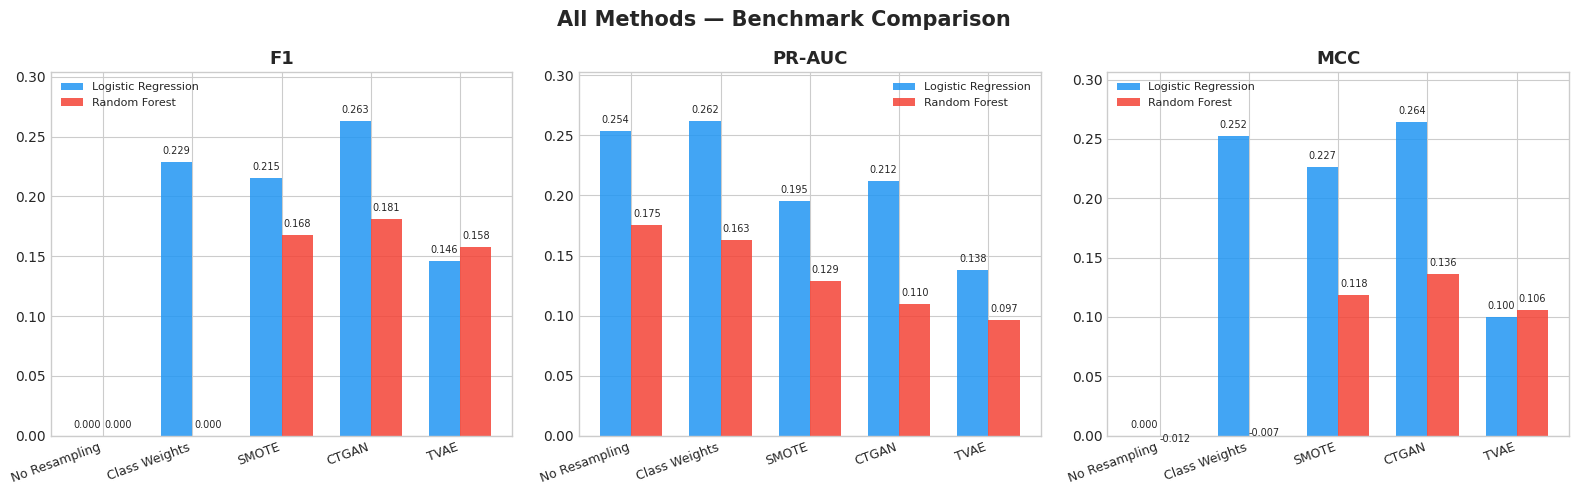

In [9]:
methods   = ['No Resampling', 'Class Weights', 'SMOTE', 'CTGAN', 'TVAE']
metrics   = ['F1', 'PR-AUC', 'MCC']
clfs      = ['Logistic Regression', 'Random Forest']
colors    = {'Logistic Regression': '#2196F3', 'Random Forest': '#F44336'}
x         = np.arange(len(methods))
width     = 0.35

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, metrics):
    for i, clf_name in enumerate(clfs):
        vals = [
            results_df[(results_df['Method'] == m) & (results_df['Classifier'] == clf_name)][metric].values[0]
            for m in methods
        ]
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=clf_name,
                      color=colors[clf_name], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.1)
    ax.legend(fontsize=8)

plt.suptitle('All Methods — Benchmark Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/benchmark_bar.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Heatmap

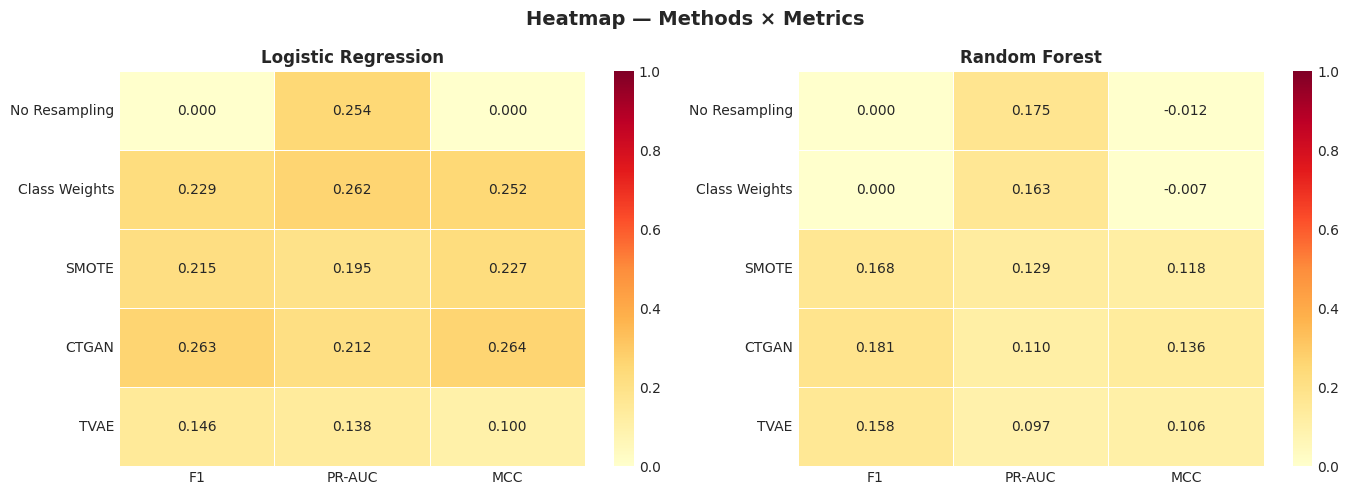

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, clf_name in zip(axes, clfs):
    subset = results_df[results_df['Classifier'] == clf_name].set_index('Method')[metrics]
    subset = subset.reindex(methods)
    sns.heatmap(subset, annot=True, fmt='.3f', cmap='YlOrRd',
                vmin=0, vmax=1, ax=ax, linewidths=0.5)
    ax.set_title(clf_name, fontsize=12, fontweight='bold')
    ax.set_ylabel('')

plt.suptitle('Heatmap — Methods × Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/benchmark_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Precision-Recall Curves

PR curves show the precision-recall trade-off across all thresholds — more informative than a single F1 score on imbalanced data.

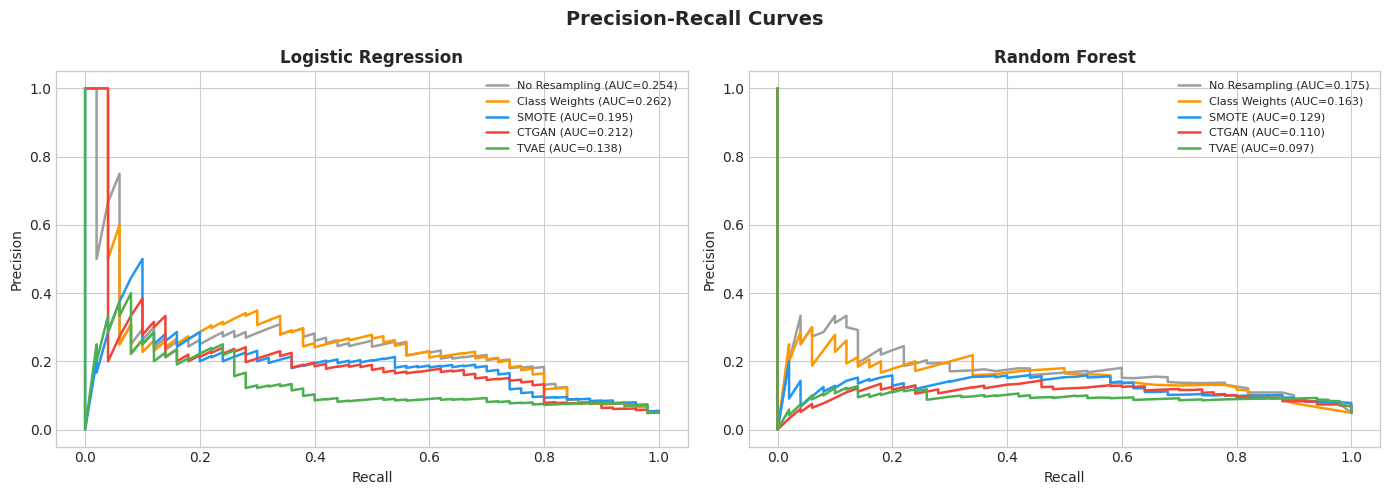

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
method_colors = {
    'No Resampling': '#9E9E9E',
    'Class Weights': '#FF9800',
    'SMOTE':         '#2196F3',
    'CTGAN':         '#F44336',
    'TVAE':          '#4CAF50',
}

# Map each method to its correct y_test
y_test_map = {
    'No Resampling': y_test,
    'Class Weights': y_test,
    'SMOTE':         y_test,
    'CTGAN':         y_test_ctgan,
    'TVAE':          y_test_tvae,
}

for ax, clf_name in zip(axes, clfs):
    for method in methods:
        _, y_prob = trained_models[f'{method}_{clf_name}']
        y_true    = y_test_map[method]
        prec, rec, _ = precision_recall_curve(y_true, y_prob)
        pr_auc = average_precision_score(y_true, y_prob)
        ax.plot(rec, prec, label=f'{method} (AUC={pr_auc:.3f})',
                color=method_colors[method], linewidth=1.8)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(clf_name, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Precision-Recall Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Best Model Deep Dive

Identify the best model by F1 and analyse in detail.

In [12]:
best = results_df.iloc[0]
print(f'Best model: [{best["Method"]}] {best["Classifier"]}')
print(f'  F1: {best["F1"]} | PR-AUC: {best["PR-AUC"]} | MCC: {best["MCC"]}')

best_clf, best_prob = trained_models[f'{best["Method"]}_{best["Classifier"]}']
best_y_test = y_test_map[best['Method']]
best_pred   = best_clf.predict(
    X_test_ctgan if best['Method'] == 'CTGAN' else
    X_test_tvae  if best['Method'] == 'TVAE'  else X_test_s
)

print('\n' + classification_report(best_y_test, best_pred, target_names=['No Stroke', 'Stroke']))

Best model: [CTGAN] Logistic Regression
  F1: 0.2629 | PR-AUC: 0.2118 | MCC: 0.2644

              precision    recall  f1-score   support

   No Stroke       0.98      0.83      0.90       972
      Stroke       0.16      0.66      0.26        50

    accuracy                           0.82      1022
   macro avg       0.57      0.74      0.58      1022
weighted avg       0.94      0.82      0.87      1022



### 6.1 Confusion Matrix

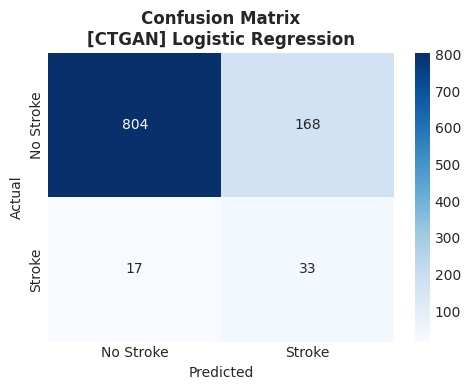

In [13]:
cm_vals = confusion_matrix(best_y_test, best_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_vals, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix\n[{best["Method"]}] {best["Classifier"]}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Feature Importance (Random Forest only)

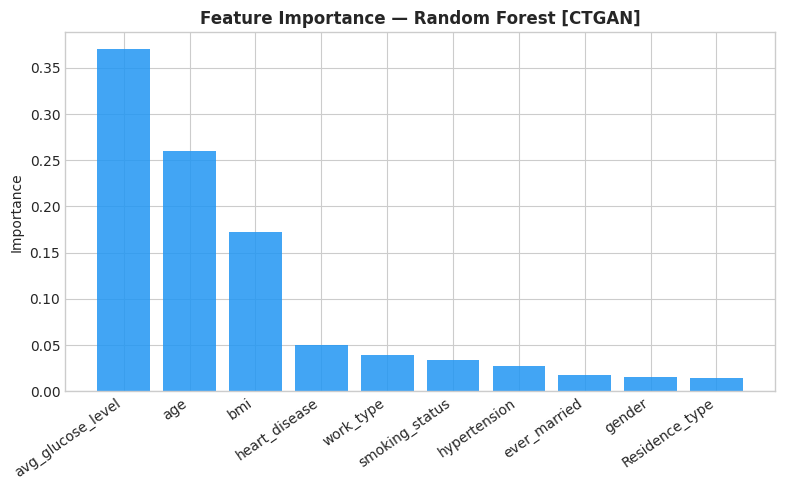

In [14]:
# Find best Random Forest model
rf_results = results_df[results_df['Classifier'] == 'Random Forest']
best_rf_method = rf_results.iloc[0]['Method']
best_rf, _ = trained_models[f'{best_rf_method}_Random Forest']

feature_names = NUMERICAL + CATEGORICAL
importances   = best_rf.feature_importances_
sorted_idx    = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(len(feature_names)), importances[sorted_idx], color='#2196F3', alpha=0.85)
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels([feature_names[i] for i in sorted_idx], rotation=35, ha='right')
ax.set_title(f'Feature Importance — Random Forest [{best_rf_method}]',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary

Key findings from the benchmark:

In [15]:
print('=== Benchmark Summary ===')
print(f"\nBest overall (F1): [{results_df.iloc[0]['Method']}] {results_df.iloc[0]['Classifier']}")
print(f"  F1={results_df.iloc[0]['F1']} | PR-AUC={results_df.iloc[0]['PR-AUC']} | MCC={results_df.iloc[0]['MCC']}")

print('\nRanking by F1:')
for _, row in results_df.iterrows():
    print(f"  {row['Method']:<18} {row['Classifier']:<22} F1={row['F1']}")

# Does generative AI beat SMOTE?
smote_f1 = results_df[results_df['Method'] == 'SMOTE']['F1'].max()
gen_f1   = results_df[results_df['Method'].isin(['CTGAN', 'TVAE'])]['F1'].max()
print(f'\nSMOTE best F1:      {smote_f1:.4f}')
print(f'Generative best F1: {gen_f1:.4f}')
print(f'Generative AI beats SMOTE: {gen_f1 > smote_f1}')

=== Benchmark Summary ===

Best overall (F1): [CTGAN] Logistic Regression
  F1=0.2629 | PR-AUC=0.2118 | MCC=0.2644

Ranking by F1:
  CTGAN              Logistic Regression    F1=0.2629
  Class Weights      Logistic Regression    F1=0.2286
  SMOTE              Logistic Regression    F1=0.2151
  CTGAN              Random Forest          F1=0.1809
  SMOTE              Random Forest          F1=0.1679
  TVAE               Random Forest          F1=0.1579
  TVAE               Logistic Regression    F1=0.1458
  No Resampling      Logistic Regression    F1=0.0
  No Resampling      Random Forest          F1=0.0
  Class Weights      Random Forest          F1=0.0

SMOTE best F1:      0.2151
Generative best F1: 0.2629
Generative AI beats SMOTE: True
